## 留意事項

- 本資料は教育・情報提供を目的とした検証メモであり、特定銘柄・取引手法の売買推奨ではありません。
- バックテスト結果は過去データに基づく試算であり、将来成果を保証しません。
- 小型アルト先物は、急変動・板薄・スリッページ・funding・強制清算リスクが大きいです。
- このノートブックの検証は、手数料・約定・資金調達率・流動性を完全には再現していません。
- 実運用する場合は、別途フォワード検証、発注制御、リスク上限、停止条件を必ず確認してください。

# 2026/06 フォワード結果の反省から仮説立案、実行

## botter会 先物乖離編

> **対象**: 裁量取引の経験をベースに、AIやPythonでボット検証を始めたい方  
> **会の目的**: 仮説 → 実装 → 検証 → 共有のサイクルを回し、ボット開発を続けること  
> **今回の問い**: A0フォワードで出たマイナスPnLは、なぜ利益を取れなかったのか  
> **今回の結論**: A0本体はTOP2維持。別候補として `S0 raw basis < 0, Top2, lag2 short` が有望。


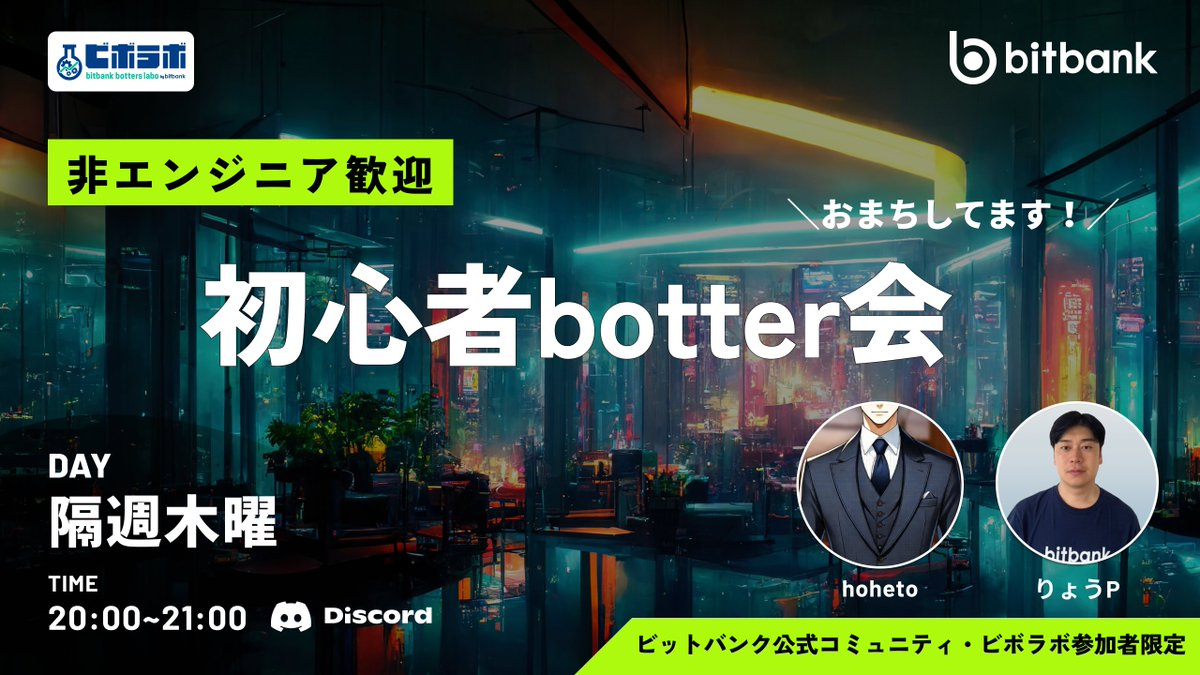

In [1]:
from pathlib import Path
from IPython.display import display, Image

OPENING_IMAGE = Path("botterkai.jpeg")

if OPENING_IMAGE.exists():
    display(Image(filename=str(OPENING_IMAGE), width=900))
else:
    print("Opening image is not found. Continue without it:", OPENING_IMAGE.name)

### 入力ファイル

配布時の入力ファイルは、できるだけ少なくしています。

- `master_current.csv`
- `future_ohlc_selected_a0.csv`
- `botterkai.jpeg`（冒頭キービジュアル）

追加で、パンプ継続リスク検証の集計CSVを使います。  
これはOI/FRなど、元のOHLCVだけでは再現しづらい外部取得済み特徴量を含むためです。

- `a0_daily_pnl_btc_background_20260617_111554.csv`（A0
フォワード日次確認用の小さいCSV）
- `a0_pump_continuation_candidate1_curves.csv`
- `a0_pump_continuation_candidate1_summary.csv`
- `a0_pump_continuation_candidate1_component_summary.csv`
- `a0_pump_continuation_candidate1_grid.csv`
- `a0_rank2_oi_basis_filter_curves.csv`
- `a0_rank2_oi_basis_filter_summary.csv`
- `a0_rank2_oi_basis_quadrant_summary.csv`
- `a0_candidate_other_controls_summary.csv`

注: 詳細なポジション明細CSVや重い全カーブCSVは配布対象から外し、問いから結論への流れに必要な集計CSVだけを使います。

生成されたグラフは `output_recomputed_event_20260618/` にPNGとして保存され、同時にノートブック上にも表示されます。

In [ ]:
from pathlib import Path
import os
import sys
import tempfile
import warnings

MPLCONFIG_DIR = Path(tempfile.gettempdir()) / "csvs_matplotlib_cache"
XDG_CACHE_DIR = Path(tempfile.gettempdir()) / "csvs_xdg_cache"
MPLCONFIG_DIR.mkdir(exist_ok=True)
XDG_CACHE_DIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIG_DIR))
os.environ.setdefault("XDG_CACHE_HOME", str(XDG_CACHE_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display, Image

warnings.filterwarnings("ignore")

# 配布先での置き方を固定しないため、CSVを複数候補から探します。
# 対応する置き方:
# 1. ノートブックと同じフォルダに全CSVを置く
# 2. master/futureを data/ に置き、検証CSVを forward_test_a0_binance/visualizations/ に置く
# 3. このリポジトリの basis_kasetsu/ 構成のまま実行する
BASE = Path.cwd().resolve()
CANDIDATE_BASES = []
for root in [
    BASE,
    BASE / "basis_kasetsu",
    BASE.parent,
    BASE.parent / "basis_kasetsu",
    Path(".").resolve(),
]:
    if root not in CANDIDATE_BASES:
        CANDIDATE_BASES.append(root)


def display_path(path):
    path = Path(path)
    try:
        return str(path.resolve().relative_to(BASE)) or "."
    except ValueError:
        return path.name


def find_input_file(filename, subdirs=(), required=True):
    candidates = []
    for root in CANDIDATE_BASES:
        candidates.append(root / filename)
        for subdir in subdirs:
            candidates.append(root / subdir / filename)
    for path in candidates:
        if path.exists():
            return path
    if required:
        tried = "\n".join(display_path(p) for p in candidates)
        raise FileNotFoundError(f"Required input file not found: {filename}\nTried:\n{tried}")
    return candidates[0]

DATA_DIR = BASE / "data"
VIS_DIR = BASE / "forward_test_a0_binance" / "visualizations"
OUT_DIR = BASE / "output_recomputed_event_20260618"
OUT_DIR.mkdir(exist_ok=True)

MASTER_CSV = find_input_file("master_current.csv", subdirs=["data"])
FUTURE_CSV = find_input_file("future_ohlc_selected_a0.csv", subdirs=["data"])
FORWARD_CSV = find_input_file(
    "a0_daily_pnl_btc_background_20260617_111554.csv",
    subdirs=["forward_test_a0_binance/visualizations", "visualizations", "data"],
)
OPENING_IMAGE = find_input_file("botterkai.jpeg", subdirs=["images", "assets"], required=False)

DEFAULT_COST_BPS = 8.0
PRACTICAL_COST_BPS = 10.0
TRADING_DAYS = 252

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 170
plt.rcParams["axes.unicode_minus"] = False
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
for font in ["Hiragino Sans", "YuGothic", "AppleGothic", "DejaVu Sans"]:
    if font in available_fonts:
        plt.rcParams["font.family"] = [font]
        break

print("Working directory:", display_path(BASE))
print("master:", MASTER_CSV.exists(), display_path(MASTER_CSV))
print("future:", FUTURE_CSV.exists(), display_path(FUTURE_CSV))
print("forward:", FORWARD_CSV.exists(), display_path(FORWARD_CSV))
print("opening image:", OPENING_IMAGE.exists(), display_path(OPENING_IMAGE))

## 0. 今日のbotter会

botter会は、ボット開発・検証を続けるための会です。

- 取引アイデアを言語化する
- 実装できるルールに落とす
- バックテストで確認する
- 良かった点だけでなく、ダメだった点も残す
- 次に検証すべき仮説を決める

今回は、A0フォワードで出たマイナスPnLを起点にします。

```text
添付画像のマイナスPnL日はなぜ利益を取れなかったのか
↓
BTC相場と関係あるのか
↓
BTC下落時なのになぜショートで負けたのか
↓
実はBTC連動ではなく、個別アルトのパンプ継続ではないか
↓
rank2が原因か
↓
rank2を消すべきか
↓
消すと長期では弱い
↓
パンプ継続を判定する指標はあるか
↓
強い改善ロジックはまだない
↓
ロング探索も試すが、先物乖離主軸では弱い
↓
backwardationは「安い」ではなく「弱さ」と見る
↓
S0 weak short を別候補として検証
```

この順番が重要です。いきなりS0を探したのではなく、A0の負け方を説明する過程で、ロングではなく弱さ継続ショートの仮説に移りました。

冒頭画像だけは資料用アセットとして読み込みます。以降の検証グラフはCSVから再計算して生成します。

## 1. データ品質チェック

ほへとさんの分析教材をもとにチェッカーを作成しました。

今回OHLCVを使うため、最初にBTCの日足OHLCVを `data_checker.py` で確認します。ここがCRITICALなら分析を止めます。

配布先で `data_checker.py` がない場合でも、ノートブック自体は続行できます。  
ただし自分の環境では、分析前にデータ品質を確認する前提です。

In [3]:
future_raw = pd.read_csv(FUTURE_CSV, parse_dates=["date"])

checker_paths = [
    BASE.parent / "hohetosensei",
    BASE / "hohetosensei",
    Path.cwd() / "hohetosensei",
]
for p in checker_paths:
    if (p / "data_checker.py").exists():
        sys.path.append(str(p))
        break

try:
    from data_checker import check_and_clean
    btc_for_check = (
        future_raw.loc[future_raw["symbol"].eq("BTC"), ["date", "open", "high", "low", "close", "volume"]]
        .sort_values("date")
        .reset_index(drop=True)
    )
    btc_clean, report = check_and_clean(btc_for_check, source_name="BTCUSDT futures daily")
    print(report.summary())
    if report.worst_level == "CRITICAL":
        raise RuntimeError("Data quality is CRITICAL. Stop before backtest.")
except ModuleNotFoundError:
    print("data_checker.py が見つからない環境です。配布先ではこのセルをスキップして続行できます。")

data_checker.py が見つからない環境です。配布先ではこのセルをスキップして続行できます。


## 2. 共通ロジック

ここで特徴量、レジーム、日次PnL計算をすべて定義します。

### A0の基本ロジック

`basis = future_close / spot_close - 1`

`demean = basis - basis.shift(1).rolling(21).mean()`

`ret1 = future_close.pct_change(1)`

日次クロスセクションで `demean` と `ret1` を順位化し、`score = 0.70 * demean_rank + 0.30 * ret1_rank` を作ります。

（A0はスコア上位Top2をショートし、翌日Openで入り、同日Closeで決済する平均回帰ショートです）

In [ ]:
master = pd.read_csv(MASTER_CSV, parse_dates=["date"])
future = future_raw.copy()

ohlc = future.rename(
    columns={
        "open": "fu_open",
        "high": "fu_high",
        "low": "fu_low",
        "close": "fu_ohlc_close",
        "volume": "fu_ohlc_volume",
    }
)

df = master.merge(
    ohlc[["date", "symbol", "fu_open", "fu_high", "fu_low", "fu_ohlc_close", "fu_ohlc_volume"]],
    on=["date", "symbol"],
    how="inner",
)
df = df.sort_values(["symbol", "date"]).reset_index(drop=True)

df["basis"] = df["fu_close"] / df["sp_close"] - 1.0
g = df.groupby("symbol", sort=False)
df["ret1"] = g["fu_close"].pct_change(1)
df["ret3"] = g["fu_close"].pct_change(3)
df["basis_mean21_prev"] = g["basis"].transform(lambda s: s.shift(1).rolling(21, min_periods=10).mean())
df["basis_std21_prev"] = g["basis"].transform(lambda s: s.shift(1).rolling(21, min_periods=10).std())
df["basis_demean"] = df["basis"] - df["basis_mean21_prev"]
df["basis_z"] = (df["basis"] - df["basis_mean21_prev"]) / df["basis_std21_prev"]

for lag in [1, 2, 3]:
    df[f"entry_open_lag{lag}"] = g["fu_open"].shift(-lag)
    df[f"exit_close_lag{lag}"] = g["fu_ohlc_close"].shift(-lag)
    df[f"oc_ret_lag{lag}"] = df[f"exit_close_lag{lag}"] / df[f"entry_open_lag{lag}"] - 1.0

SIGNAL_EXCLUDE = {
    "BTC", "USDC", "USDT", "BUSD", "FDUSD", "TUSD", "DAI",
    "PAXG", "XAUT",
}
sig = df.loc[~df["symbol"].isin(SIGNAL_EXCLUDE)].copy()

sig["demean_rank"] = sig.groupby("date")["basis_demean"].rank(pct=True) - 0.5
sig["ret1_rank"] = sig.groupby("date")["ret1"].rank(pct=True) - 0.5
sig["score_a0"] = 0.70 * sig["demean_rank"] + 0.30 * sig["ret1_rank"]

btc = future.loc[future["symbol"].eq("BTC"), ["date", "open", "high", "low", "close", "volume"]].sort_values("date").copy()
btc["ma200"] = btc["close"].rolling(200, min_periods=180).mean()
btc["btc_ma200_gap"] = btc["close"] / btc["ma200"] - 1.0
btc["btc_ma200_gap_ma7"] = btc["btc_ma200_gap"].rolling(7, min_periods=3).mean()
btc["btc_long_allowed"] = btc["btc_ma200_gap_ma7"] > 0

px = future.pivot(index="date", columns="symbol", values="close").sort_index()
solbtc = (px["SOL"] / px["BTC"]).rename("solbtc").to_frame()
solbtc["solbtc_ma180"] = solbtc["solbtc"].rolling(180, min_periods=120).mean()
solbtc["a0_current_regime"] = solbtc["solbtc"] < solbtc["solbtc_ma180"]
regimes = (
    btc[["date", "close", "ma200", "btc_ma200_gap_ma7", "btc_long_allowed"]]
    .merge(solbtc.reset_index()[["date", "solbtc", "solbtc_ma180", "a0_current_regime"]], on="date", how="left")
    .rename(columns={"close": "btc_close"})
)
sig = sig.merge(regimes[["date", "btc_long_allowed", "a0_current_regime"]], on="date", how="left")

print("feature rows:", len(sig), "symbols:", sig["symbol"].nunique(), "date:", sig["date"].min().date(), "to", sig["date"].max().date())
display(sig[["date", "symbol", "basis", "basis_demean", "basis_z", "ret1", "score_a0"]].head())

feature rows: 304064 symbols: 294 date: 2021-01-01 to 2026-05-23


,date,symbol,basis,basis_demean,basis_z,ret1,score_a0
0,2025-09-22,0G,-0.019570,NaN,NaN,NaN,NaN
1,2025-09-23,0G,-0.018418,NaN,NaN,0.203107,NaN
2,2025-09-24,0G,-0.004016,NaN,NaN,-0.126667,NaN
3,2025-09-25,0G,-0.013327,NaN,NaN,-0.224699,NaN
4,2025-09-26,0G,-0.002881,NaN,NaN,-0.050818,NaN


In [5]:
def perf_stats(daily_bps, label=None):
    s = pd.Series(daily_bps).dropna()
    if len(s) == 0:
        return {
            "label": label, "days": 0, "cum_bps": np.nan, "avg_bps": np.nan,
            "sharpe": np.nan, "max_dd_bps": np.nan, "win_rate": np.nan,
        }
    cum = s.cumsum()
    dd = cum - cum.cummax()
    std = s.std(ddof=0)
    return {
        "label": label,
        "days": int(len(s)),
        "cum_bps": float(s.sum()),
        "avg_bps": float(s.mean()),
        "sharpe": float(s.mean() / std * np.sqrt(TRADING_DAYS)) if std and np.isfinite(std) else np.nan,
        "max_dd_bps": float(dd.min()),
        "win_rate": float((s > 0).mean()),
    }


def select_positions(
    data,
    score_col,
    *,
    highest=True,
    top_n=2,
    lag=1,
    direction="short",
    cost_bps=DEFAULT_COST_BPS,
    start=None,
    end=None,
    eligible=None,
    label=None,
):
    x = data.copy()
    if start is not None:
        x = x[x["date"] >= pd.Timestamp(start)]
    if end is not None:
        x = x[x["date"] <= pd.Timestamp(end)]
    if eligible is not None:
        x = x[eligible(x)]
    ret_col = f"oc_ret_lag{lag}"
    x = x.dropna(subset=[score_col, ret_col]).copy()
    x["_rank"] = x.groupby("date")[score_col].rank(method="first", ascending=not highest)
    x = x[x["_rank"] <= top_n].copy()
    sign = -1.0 if direction == "short" else 1.0
    x["position_bps"] = sign * x[ret_col] * 10000 - cost_bps
    x["strategy"] = label or score_col
    daily = x.groupby("date")["position_bps"].mean().sort_index()
    daily.name = label or score_col
    return x, daily


def daily_by_rank(data, score_col, *, lag=1, cost_bps=DEFAULT_COST_BPS, start=None, end=None, eligible=None):
    x, _ = select_positions(
        data, score_col, highest=True, top_n=2, lag=lag, direction="short",
        cost_bps=cost_bps, start=start, end=end, eligible=eligible, label="a0_top2"
    )
    pivot = x.pivot_table(index="date", columns="_rank", values="position_bps", aggfunc="mean").sort_index()
    out = pd.DataFrame(index=pivot.index)
    out["rank1"] = pivot.get(1.0)
    out["rank2"] = pivot.get(2.0)
    out["top2"] = pivot[[c for c in [1.0, 2.0] if c in pivot.columns]].mean(axis=1)
    return out


def add_btc_background(ax, start=None, end=None, alpha=0.13):
    b = btc.copy()
    if start is not None:
        b = b[b["date"] >= pd.Timestamp(start)]
    if end is not None:
        b = b[b["date"] <= pd.Timestamp(end)]
    if b.empty:
        return None
    ax2 = ax.twinx()
    ax2.plot(b["date"], b["close"], color="#111827", alpha=alpha, lw=2.0, label="BTC close")
    ax2.set_yscale("log")
    ax2.set_ylabel("BTC close log", color="#6b7280")
    ax2.tick_params(axis="y", colors="#6b7280")
    return ax2


def savefig(fig, name):
    path = OUT_DIR / name
    fig.savefig(path, bbox_inches="tight")
    return path


def plot_cum(curves, title, filename, *, start=None, end=None, btc_bg=True):
    fig, ax = plt.subplots(figsize=(11, 5.2))
    for label, daily in curves.items():
        s = pd.Series(daily).dropna()
        if start is not None:
            s = s[s.index >= pd.Timestamp(start)]
        if end is not None:
            s = s[s.index <= pd.Timestamp(end)]
        ax.plot(s.index, s.cumsum(), lw=2.0, label=label)
    ax.axhline(0, color="#111827", lw=0.8)
    ax.set_title(title, loc="left", fontsize=14, fontweight="bold")
    ax.set_ylabel("cumulative net PnL bps")
    ax.legend(loc="best", fontsize=9)
    if btc_bg:
        add_btc_background(ax, start, end)
    fig.tight_layout()
    savefig(fig, filename)
    plt.show()

def stats_table(curves, start=None, end=None):
    rows = []
    for label, daily in curves.items():
        s = pd.Series(daily).dropna()
        if start is not None:
            s = s[s.index >= pd.Timestamp(start)]
        if end is not None:
            s = s[s.index <= pd.Timestamp(end)]
        rows.append(perf_stats(s, label))
    return pd.DataFrame(rows).set_index("label").round(3)

## 3. 起点: A0フォワード結果のマイナスPnLはBTC相場だけで説明できるか

最初の問いは、添付画像のマイナスPnLです。

```text
ショート戦略なのに、BTCが下落している日に負けている
```

もし負けの主因がBTC方向なら、BTC下落日はショートに追い風のはずです。  
それでも負けたので、BTC連動ではなく、ショートした個別アルトが翌日も上がった可能性を疑います。

ここではまず、日次PnLとBTC背景を重ねて確認します。

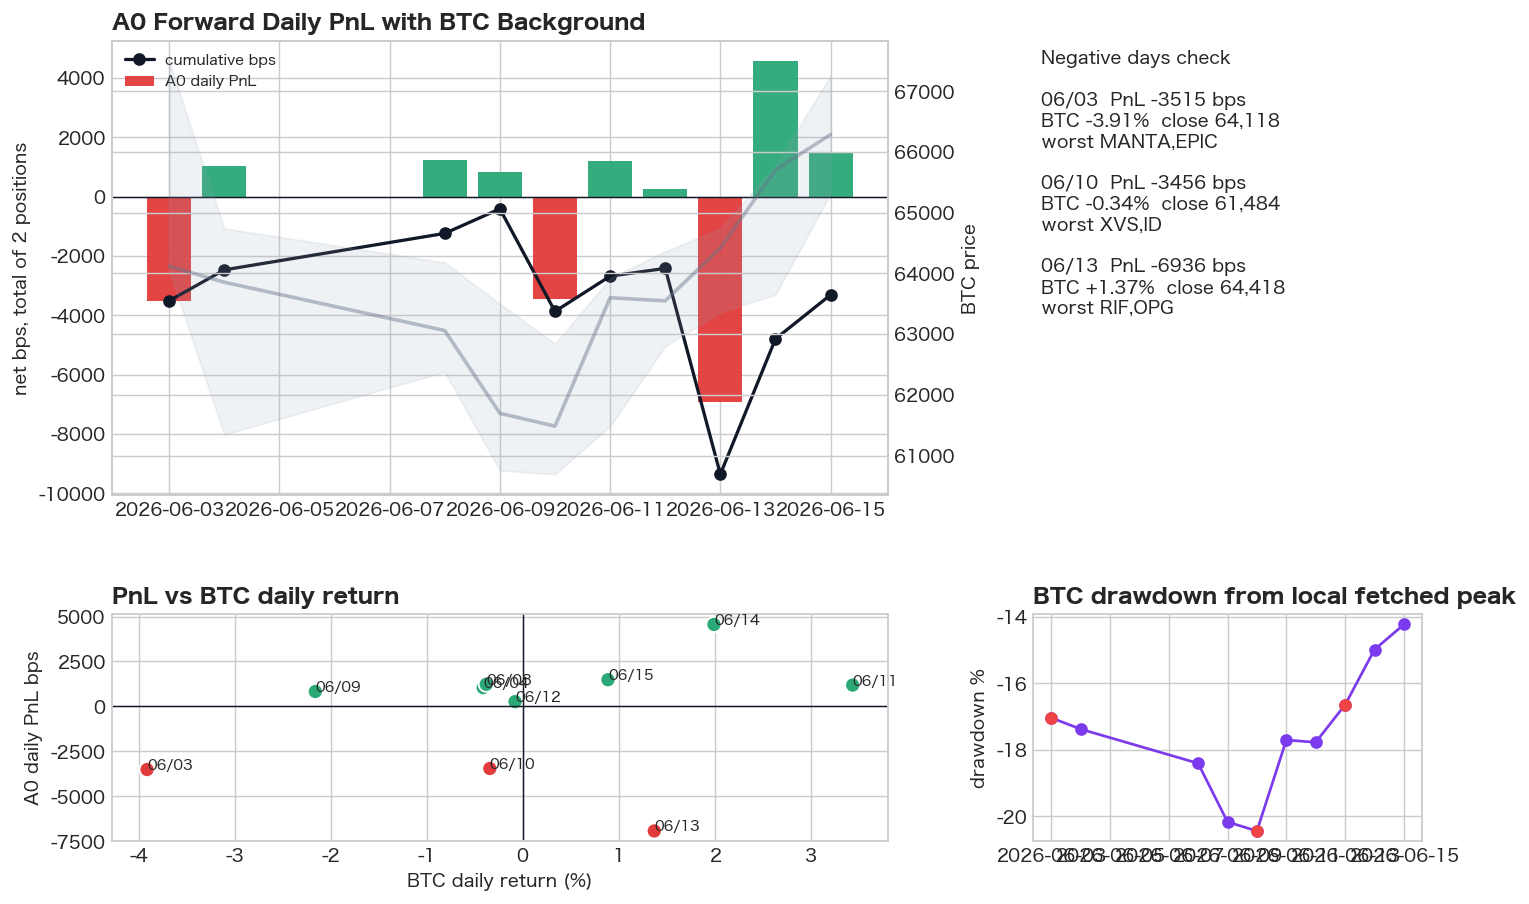

In [6]:
if FORWARD_CSV.exists():
    fwd = pd.read_csv(FORWARD_CSV, parse_dates=["signal_date", "date"]).sort_values("signal_date")
    fig = plt.figure(figsize=(13, 8))
    gs = fig.add_gridspec(2, 2, height_ratios=[2, 1], width_ratios=[2, 1], hspace=0.35, wspace=0.25)

    ax = fig.add_subplot(gs[0, 0])
    colors = np.where(fwd["total_bps"] >= 0, "#2aa876", "#e23b3b")
    ax.bar(fwd["signal_date"], fwd["total_bps"], color=colors, width=0.8, alpha=0.95, label="A0 daily PnL")
    ax.plot(fwd["signal_date"], fwd["cum_bps"], color="#111827", marker="o", lw=1.8, label="cumulative bps")
    ax.axhline(0, color="#111827", lw=0.8)
    ax.set_title("A0 Forward Daily PnL with BTC Background", loc="left", fontweight="bold")
    ax.set_ylabel("net bps, total of 2 positions")
    ax.legend(loc="upper left", fontsize=8)
    ax2 = ax.twinx()
    ax2.plot(fwd["signal_date"], fwd["close"], color="#64748b", lw=2.0, alpha=0.45, label="BTC close")
    ax2.fill_between(fwd["signal_date"], fwd["low"], fwd["high"], color="#94a3b8", alpha=0.14)
    ax2.set_ylabel("BTC price")

    ax = fig.add_subplot(gs[0, 1])
    neg = fwd[fwd["total_bps"] < 0].copy()
    ax.axis("off")
    text = ["Negative days check"]
    for _, r in neg.iterrows():
        text.append(
            f"{r['signal_date']:%m/%d}  PnL {r['total_bps']:.0f} bps\n"
            f"BTC {r['btc_ret_pct']:+.2f}%  close {r['close']:,.0f}\n"
            f"worst {r['worst_symbol']}"
        )
    ax.text(0.02, 0.98, "\n\n".join(text), va="top", fontsize=10)

    ax = fig.add_subplot(gs[1, 0])
    ax.scatter(fwd["btc_ret_pct"], fwd["total_bps"], c=colors, s=70, edgecolor="white")
    for _, r in fwd.iterrows():
        ax.text(r["btc_ret_pct"], r["total_bps"], r["signal_date"].strftime("%m/%d"), fontsize=8)
    ax.axhline(0, color="#111827", lw=0.8)
    ax.axvline(0, color="#111827", lw=0.8)
    ax.set_title("PnL vs BTC daily return", loc="left", fontweight="bold")
    ax.set_xlabel("BTC daily return (%)")
    ax.set_ylabel("A0 daily PnL bps")

    ax = fig.add_subplot(gs[1, 1])
    ax.plot(fwd["signal_date"], fwd["btc_dd_pct"], color="#7c3aed", marker="o")
    ax.scatter(neg["signal_date"], neg["btc_dd_pct"], color="#ef4444", zorder=3)
    ax.set_title("BTC drawdown from local fetched peak", loc="left", fontweight="bold")
    ax.set_ylabel("drawdown %")

    fig.tight_layout()
    savefig(fig, "01_a0_forward_daily_pnl_btc_background.png")
    plt.show()
else:
    print("forward daily CSV is missing:", display_path(FORWARD_CSV))

## 4. rank2が原因か

次の仮説は `rank2` です。

A0はTop2をショートします。フォワードの大負け日に、rank1よりrank2の方が悪さをしているように見えました。  
ただし、ここでいきなりrank2を消すと、過去長期での期待値を壊す可能性があります。

そこで、rank1、rank2、Top2を分けて確認します。  
結論は「フォワードの大負けはrank2に寄ったが、rank2を単純に消すと長期の期待値を削りやすい」です。

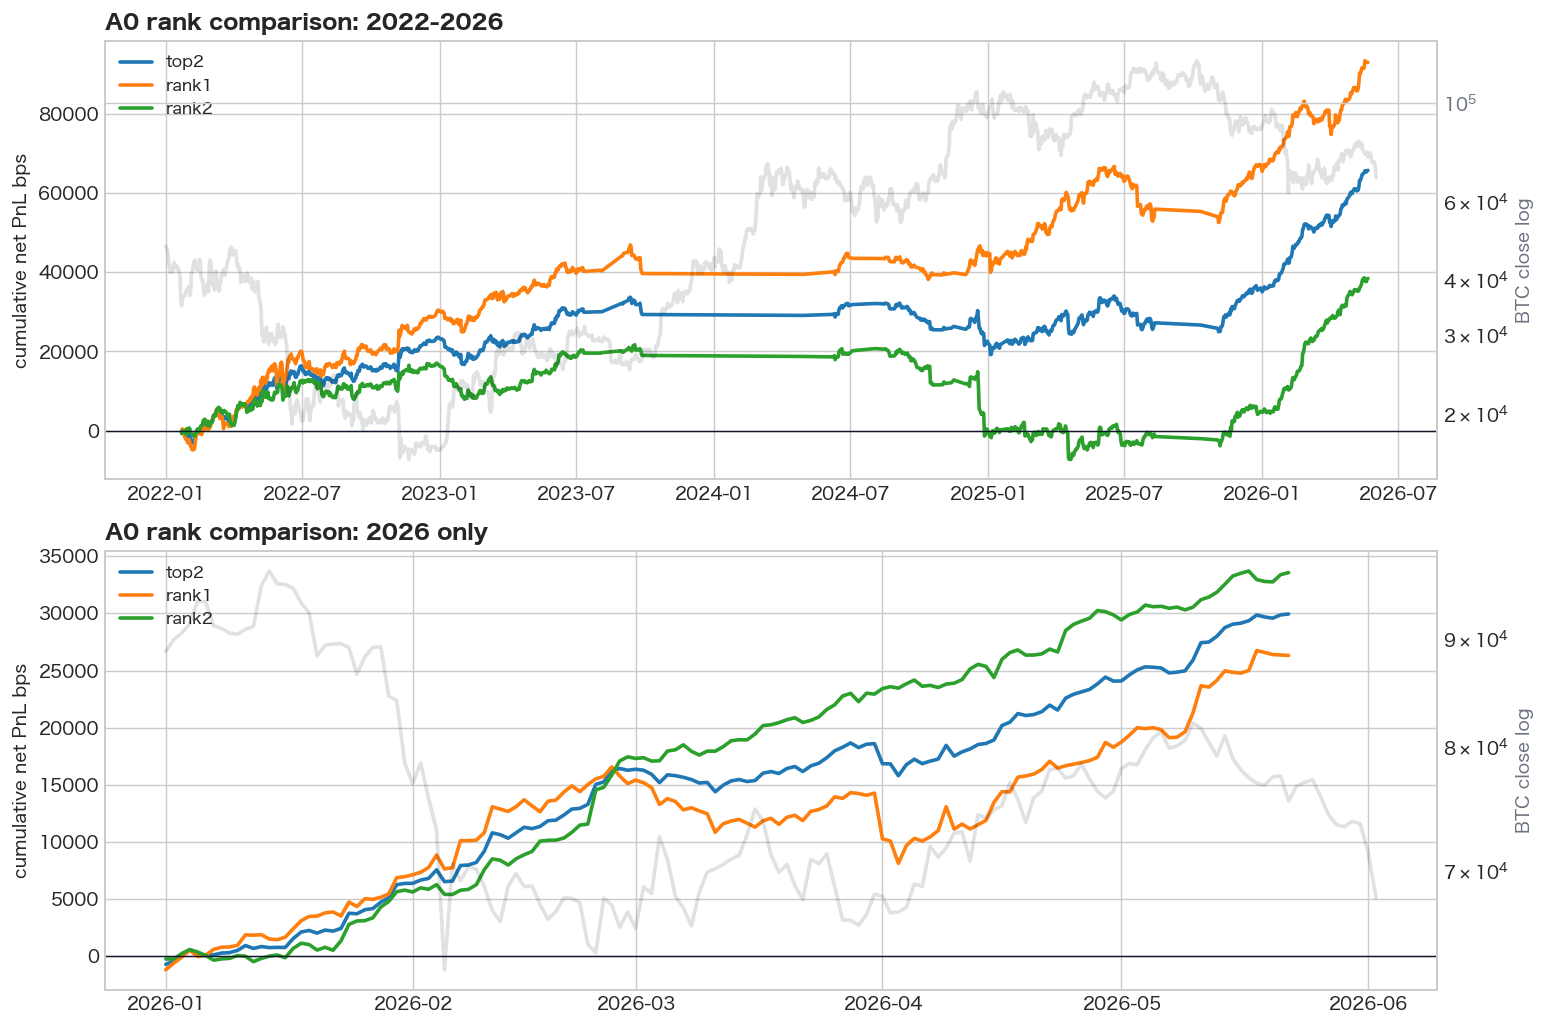

,days,cum_bps,avg_bps,sharpe,max_dd_bps,win_rate
label,,,,,,
top2,1081,65687.831,60.766,1.582,-14490.877,0.562
rank1,1081,92926.058,85.963,1.768,-14153.803,0.568
rank2,1081,38449.604,35.569,0.801,-28958.204,0.533


,days,cum_bps,avg_bps,sharpe,max_dd_bps,win_rate
label,,,,,,
top2,142,29952.912,210.936,6.653,-2866.930,0.725
rank1,142,26329.697,185.420,3.723,-8425.391,0.648
rank2,142,33576.127,236.452,7.301,-1153.038,0.711


In [7]:
a0_rank_daily = daily_by_rank(
    sig,
    "score_a0",
    lag=1,
    cost_bps=DEFAULT_COST_BPS,
    start="2022-01-01",
    eligible=lambda x: x["a0_current_regime"].fillna(False),
)
a0_rank_curves = {c: a0_rank_daily[c].dropna() for c in ["top2", "rank1", "rank2"]}

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
for ax, start, title in [
    (axes[0], "2022-01-01", "A0 rank comparison: 2022-2026"),
    (axes[1], "2026-01-01", "A0 rank comparison: 2026 only"),
]:
    for label, s in a0_rank_curves.items():
        ss = s[s.index >= pd.Timestamp(start)]
        ax.plot(ss.index, ss.cumsum(), lw=2, label=label)
    ax.axhline(0, color="#111827", lw=0.8)
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_ylabel("cumulative net PnL bps")
    ax.legend(loc="upper left", fontsize=9)
    add_btc_background(ax, start=start)
fig.tight_layout()
savefig(fig, "02_a0_rank1_rank2_top2_recomputed.png")
plt.show()

display(stats_table(a0_rank_curves, start="2022-01-01"))
display(stats_table(a0_rank_curves, start="2026-01-01"))

## 5. パンプ継続リスク指標を検証する

rank2を単純に消すと長期の期待値が落ちやすいので、次はほかの指標との組み合わせによって利益がつくれないかを確認しました。

ここで見た候補は以下です。

- BTC超過リターン: 個別アルトだけがBTCより強く上がっていないか
- 高値引け: その日のローソク足が高値圏で終わっていないか
- 出来高増加: 出来高が平常時より急増していないか
- OI急増: 先物建玉が急増していないか
- FR: fundingがショート/ロング需要の偏りを示していないか
- cooldown: 直近パンプ直後の銘柄を避けるべきか

結論として、これらは「観察指標」としては有用でした。  
しかし、A0のTOP2を明確に改善する強いフィルターにはまだなっていません。  
そのためA0本体はTOP2維持とし、通知に観察指標を追加する方針にしました。

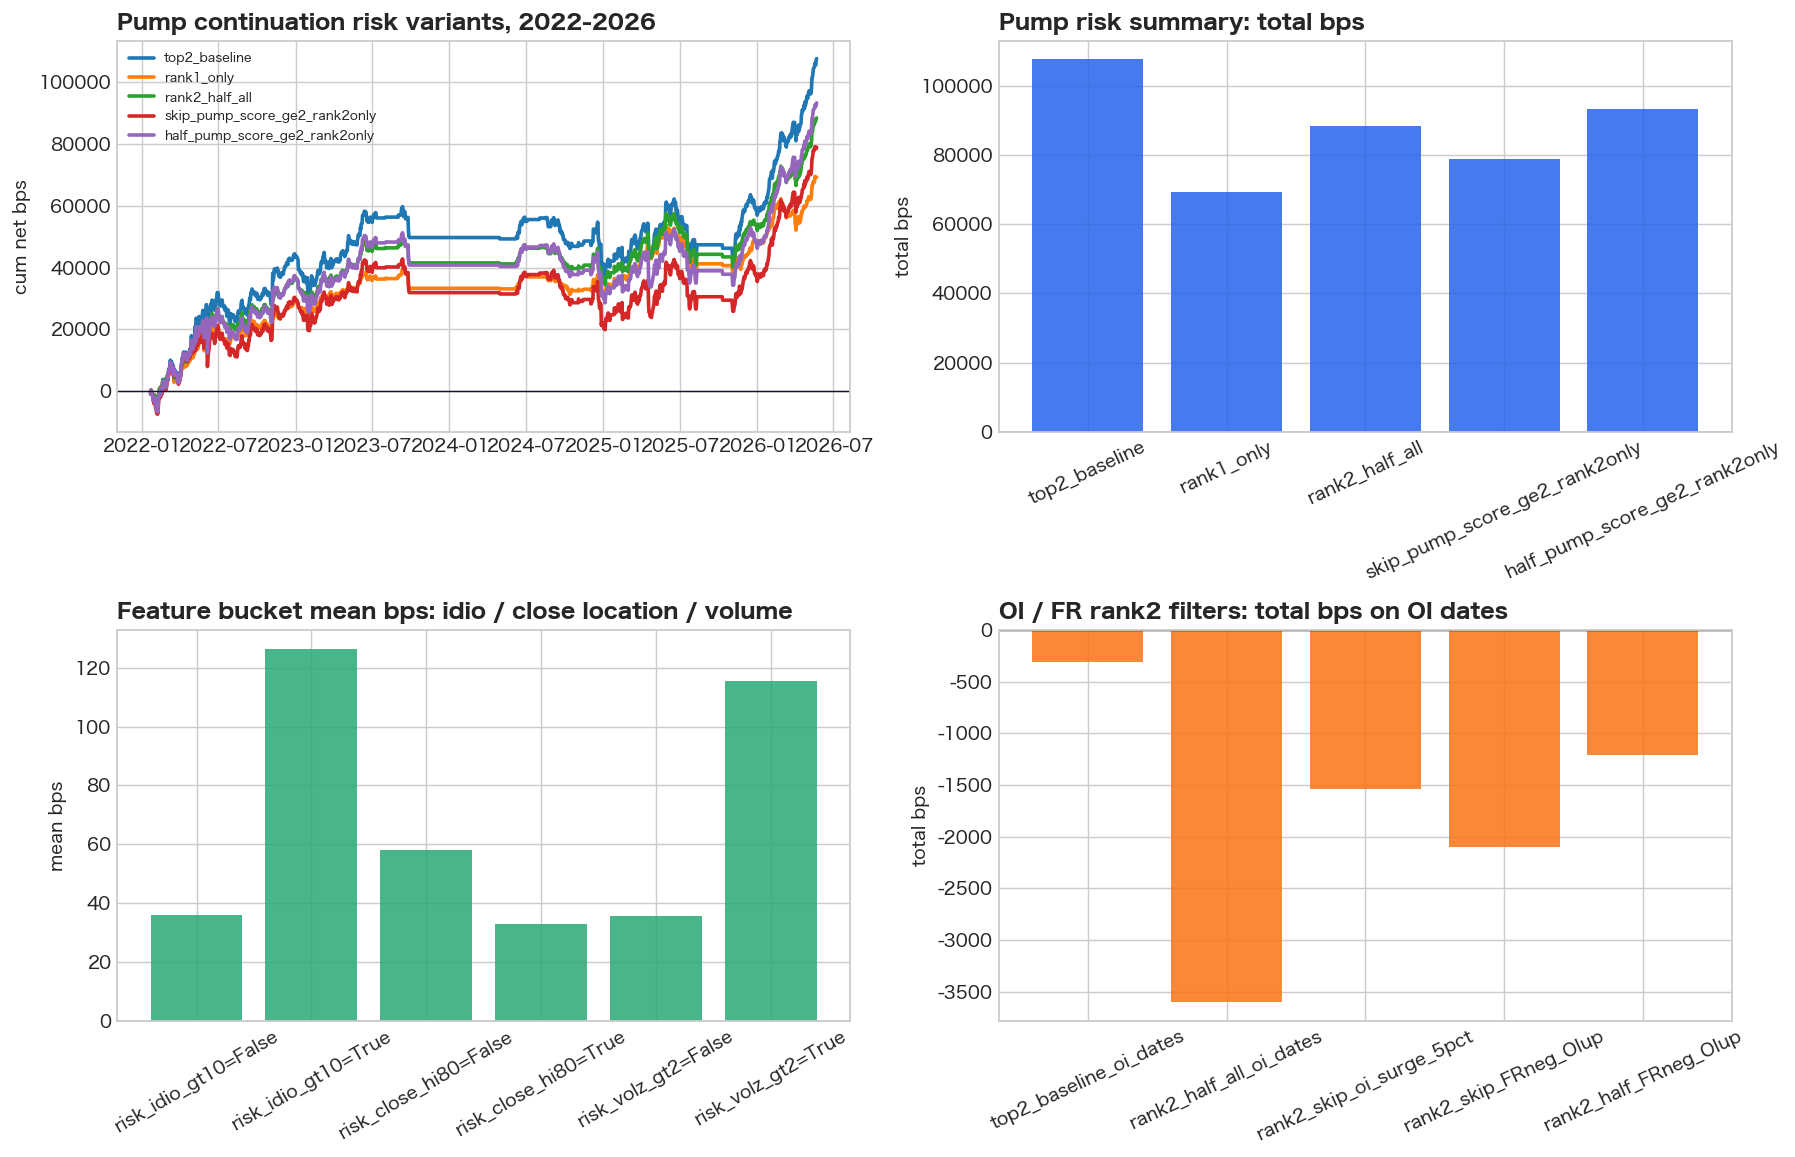

,period,variant,positions,active_days,adjusted_positions,total_bps,mean_active_day_bps,median_active_day_bps,win_rate_active_day,maxdd_bps,worst_day_bps,mean_position_bps,worst_position_bps
0,full_2022_2026,top2_baseline,2162,1081,0,107641.58,99.58,122.61,0.55,-22453.44,-10183.21,49.79,-7158.08
1,full_2022_2026,rank1_only,2162,1081,1081,69232.65,64.05,85.21,0.56,-16130.12,-7158.08,32.02,-7158.08
2,full_2022_2026,rank2_half_all,2162,1081,1081,88437.12,81.81,101.41,0.56,-17320.17,-8670.65,40.91,-7158.08
3,full_2022_2026,skip_pump_score_ge2_all,2162,1081,292,74165.20,68.61,20.41,0.51,-19342.15,-7360.89,34.30,-6500.78
4,full_2022_2026,half_pump_score_ge2_all,2162,1081,292,90903.39,84.09,113.41,0.55,-20554.10,-7360.89,42.05,-6500.78
5,full_2022_2026,skip_pump_score_ge3_all,2162,1081,63,95747.04,88.57,113.91,0.55,-22784.73,-10183.21,44.29,-7158.08
6,full_2022_2026,skip_pump_score_ge2_rank2only,2162,1081,95,78968.11,73.05,114.21,0.55,-22913.63,-10183.21,36.53,-7158.08
7,full_2022_2026,half_pump_score_ge2_rank2only,2162,1081,95,93304.84,86.31,117.72,0.55,-22683.54,-10183.21,43.16,-7158.08


,variant,positions,active_days,rank2_adjusted_positions,total_bps,mean_active_day_bps,median_active_day_bps,win_rate_active_day,maxdd_bps,worst_day_bps,best_day_bps
0,top2_baseline_oi_dates,62,31,0,-313.74,-10.12,141.59,0.58,-4283.15,-3791.63,1310.16
1,rank1_only_oi_dates,62,31,31,-6893.56,-222.37,-93.58,0.48,-6668.91,-4250.73,752.58
2,rank2_half_all_oi_dates,62,31,31,-3603.65,-116.25,153.62,0.52,-4555.57,-4021.18,959.39
3,rank2_skip_oi_up,62,31,14,-3449.20,-111.26,141.59,0.55,-5035.61,-4250.73,1310.16
4,rank2_skip_oi_surge_5pct,62,31,6,-1536.80,-49.57,141.59,0.58,-4372.80,-4250.73,1310.16
5,rank2_skip_FRneg_OIup,62,31,8,-2098.94,-67.71,141.59,0.58,-4415.45,-4250.73,1310.16
6,rank2_half_FRneg_OIup,62,31,8,-1206.34,-38.91,141.59,0.58,-4349.30,-4021.18,1310.16
7,rank2_skip_FRneg_OIsurge5pct,62,31,3,-1265.63,-40.83,141.59,0.58,-4372.80,-4250.73,1310.16
8,rank2_skip_FRneg_OIup_demean_q75,62,31,1,-308.58,-9.95,141.59,0.58,-4277.99,-3791.63,1310.16
9,rank2_skip_FRneg_OIup_demean_0.5pct,62,31,2,-776.18,-25.04,141.59,0.58,-4277.99,-3791.63,1310.16


,mode,idio_th,close_loc_th,volz_th,risk_n,risk_rate,total_bps,maxdd_bps,worst_day_bps,mean_active_day_bps,win_rate_active_day,score_total_dd
179,half,20.0,0.9,3.0,69,0.03,105984.97,-21121.87,-10183.21,98.04,0.55,100704.51
178,skip,20.0,0.9,3.0,69,0.03,104328.37,-20489.91,-10183.21,96.51,0.54,99205.89
177,half,20.0,0.9,2.5,84,0.04,103246.51,-20873.13,-10183.21,95.51,0.55,98028.23
119,half,12.5,0.9,3.0,116,0.05,102490.45,-20868.81,-10183.21,94.81,0.55,97273.25
159,half,20.0,0.7,3.0,123,0.06,101919.11,-20540.47,-7360.89,94.28,0.54,96784.00
169,half,20.0,0.8,3.0,94,0.04,101787.22,-21111.86,-10183.21,94.16,0.55,96509.25
149,half,15.0,0.9,3.0,91,0.04,101378.31,-21430.10,-10183.21,93.78,0.55,96020.79
175,half,20.0,0.9,2.0,105,0.05,100849.03,-21229.51,-7360.89,93.29,0.55,95541.66
59,half,7.5,0.9,3.0,218,0.10,99660.39,-18406.06,-10183.21,92.19,0.55,95058.88
173,half,20.0,0.9,1.5,122,0.06,100319.96,-21229.51,-7360.89,92.80,0.54,95012.58


,fr_bucket,oi_bucket,demean_q75,n,total_bps,mean_bps,median_bps,win_rate,worst_bps,oi_mean_bps,fr_mean_bps,demean_mean
0,FR missing,OI surge>=5%,demean high q75,1,254.69,254.69,254.69,1.00,254.69,784.22,NaN,0.01
1,FR missing,OI surge>=5%,demean lower,1,-289.54,-289.54,-289.54,0.00,-289.54,923.59,NaN,0.01
2,FR missing,OI up 0-5%,demean high q75,1,741.61,741.61,741.61,1.00,741.61,430.26,NaN,0.01
3,FR<0,OI down,demean high q75,3,-832.58,-277.53,-326.68,0.33,-561.05,-243.66,-6.04,0.01
4,FR<0,OI down,demean lower,9,2412.85,268.09,428.54,0.78,-732.26,-368.18,-32.40,0.00
5,FR<0,OI surge>=5%,demean lower,3,951.89,317.30,402.92,1.00,89.86,3203.01,-28.72,0.00
6,FR<0,OI up 0-5%,demean high q75,1,-5.16,-5.16,-5.16,0.00,-5.16,240.10,-0.82,0.01
7,FR<0,OI up 0-5%,demean lower,4,838.47,209.62,173.00,1.00,24.89,245.06,-27.51,0.00
8,FR>=0,OI down,demean high q75,2,635.58,317.79,317.79,0.50,-10.12,-387.57,3.03,0.01
9,FR>=0,OI down,demean lower,3,1228.52,409.51,344.06,1.00,74.37,-235.57,2.75,0.00


,variant,mode,total_bps,mean_active_day_bps,maxdd_bps,worst_day_bps,delta_total_vs_baseline,dd_improvement_vs_baseline
0,top2_baseline,baseline,107641.58,99.58,-22453.44,-10183.21,0.00,0.00
1,rank1_only,rank1_only,69232.65,64.05,-16130.12,-7158.08,-38408.93,6323.32
2,rank2_half_all,rank2_half_all,88437.12,81.81,-17320.17,-8670.65,-19204.47,5133.27
23,skip_no_pullback_close_loc_ge90,skip,101823.23,94.19,-23298.16,-10183.21,-5818.36,-844.72
24,half_no_pullback_close_loc_ge90,half,104732.40,96.88,-20348.70,-10183.21,-2909.18,2104.74
27,skip_no_pullback_idio10_close90,skip,105627.00,97.71,-19741.18,-10183.21,-2014.58,2712.27
28,half_no_pullback_idio10_close90,half,106634.29,98.64,-20884.31,-10183.21,-1007.29,1569.13
29,skip_pullback_lt20_idio10,skip,93106.11,86.13,-18743.66,-10183.21,-14535.47,3709.78


In [8]:
def read_vis_csv(name, date_cols=("signal_date", "date")):
    path = find_input_file(
        name,
        subdirs=["forward_test_a0_binance/visualizations", "visualizations", "data"],
    )
    out = pd.read_csv(path)
    for c in date_cols:
        if c in out.columns:
            out[c] = pd.to_datetime(out[c])
    return out

pump_curves = read_vis_csv("a0_pump_continuation_candidate1_curves.csv")
pump_summary = read_vis_csv("a0_pump_continuation_candidate1_summary.csv")
pump_component = read_vis_csv("a0_pump_continuation_candidate1_component_summary.csv")
pump_grid = read_vis_csv("a0_pump_continuation_candidate1_grid.csv")
oi_curves = read_vis_csv("a0_rank2_oi_basis_filter_curves.csv")
oi_summary = read_vis_csv("a0_rank2_oi_basis_filter_summary.csv")
oi_quadrant = read_vis_csv("a0_rank2_oi_basis_quadrant_summary.csv")
other_summary = read_vis_csv("a0_candidate_other_controls_summary.csv")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0, 0]
pump_variants = [
    "top2_baseline",
    "rank1_only",
    "rank2_half_all",
    "skip_pump_score_ge2_rank2only",
    "half_pump_score_ge2_rank2only",
]
pc = pump_curves[
    pump_curves["period"].eq("full_2022_2026")
    & pump_curves["variant"].isin(pump_variants)
].copy()
for variant, part in pc.groupby("variant", sort=False):
    ax.plot(part["signal_date"], part["cum"], lw=2, label=variant)
ax.axhline(0, color="#111827", lw=0.8)
ax.set_title("Pump continuation risk variants, 2022-2026", loc="left", fontweight="bold")
ax.set_ylabel("cum net bps")
ax.legend(fontsize=7, loc="best")

ax = axes[0, 1]
ps = pump_summary[
    pump_summary["period"].eq("full_2022_2026")
    & pump_summary["variant"].isin(pump_variants)
].set_index("variant").loc[pump_variants]
ax.bar(ps.index, ps["total_bps"], color="#2563eb", alpha=0.85)
ax.axhline(0, color="#111827", lw=0.8)
ax.set_title("Pump risk summary: total bps", loc="left", fontweight="bold")
ax.set_ylabel("total bps")
ax.tick_params(axis="x", rotation=25)

ax = axes[1, 0]
comp = pump_component[pump_component["feature"].isin(["risk_idio_gt10", "risk_close_hi80", "risk_volz_gt2"])].copy()
comp["bucket_label"] = comp["feature"] + "=" + comp["bucket"].astype(str)
ax.bar(comp["bucket_label"], comp["mean_bps"], color=np.where(comp["mean_bps"] >= 0, "#2aa876", "#e23b3b"), alpha=0.85)
ax.axhline(0, color="#111827", lw=0.8)
ax.set_title("Feature bucket mean bps: idio / close location / volume", loc="left", fontweight="bold")
ax.set_ylabel("mean bps")
ax.tick_params(axis="x", rotation=30)

ax = axes[1, 1]
oi_variants = [
    "top2_baseline_oi_dates",
    "rank2_half_all_oi_dates",
    "rank2_skip_oi_surge_5pct",
    "rank2_skip_FRneg_OIup",
    "rank2_half_FRneg_OIup",
]
ois = oi_summary[oi_summary["variant"].isin(oi_variants)].set_index("variant").loc[oi_variants]
ax.bar(ois.index, ois["total_bps"], color="#f97316", alpha=0.85)
ax.axhline(0, color="#111827", lw=0.8)
ax.set_title("OI / FR rank2 filters: total bps on OI dates", loc="left", fontweight="bold")
ax.set_ylabel("total bps")
ax.tick_params(axis="x", rotation=25)

fig.tight_layout()
savefig(fig, "03_pump_oi_fr_risk_controls_recomputed.png")
plt.show()

display(pump_summary[pump_summary["period"].eq("full_2022_2026")].round(2))
display(oi_summary.round(2))
display(
    pump_grid.sort_values("score_total_dd", ascending=False)
    .head(10)
    .round(2)
)
display(oi_quadrant.round(2))

other_focus = [
    "top2_baseline",
    "rank1_only",
    "rank2_half_all",
    "skip_no_pullback_close_loc_ge90",
    "half_no_pullback_close_loc_ge90",
    "skip_no_pullback_idio10_close90",
    "half_no_pullback_idio10_close90",
    "skip_pullback_lt20_idio10",
]
other = other_summary[
    other_summary["period"].eq("full_2022_2026")
    & other_summary["variant"].isin(other_focus)
].copy()
display(other[[
    "variant", "mode", "total_bps", "mean_active_day_bps", "maxdd_bps",
    "worst_day_bps", "delta_total_vs_baseline", "dd_improvement_vs_baseline"
]].round(2))

## 6. ロング探索の道へ

rank2やパンプ継続フィルターだけでは、A0を明確に改善する強い条件は見つかりませんでした。

そこで別方向として、次の問いを立てました。

```text
A0ショートが苦手な「個別アルトの上昇継続」は、
ロング専用戦略として別枠で取れないか
```

ただし、ショート戦略をロングで上書きするのは避けます。  
A0はA0として残し、ロングは別戦略候補として検証します。

最初に、ロングしてよい地合いをBTC MA200 gap MA7で確認します。  
これは `BTC close / BTC MA200 - 1` を7日平均したもので、0より上ならロング許可レジームとします。

（BTCが200日移動平均より上にいて、その状態が7日平均でもプラスなら、相場全体はリスクオン寄りとする）

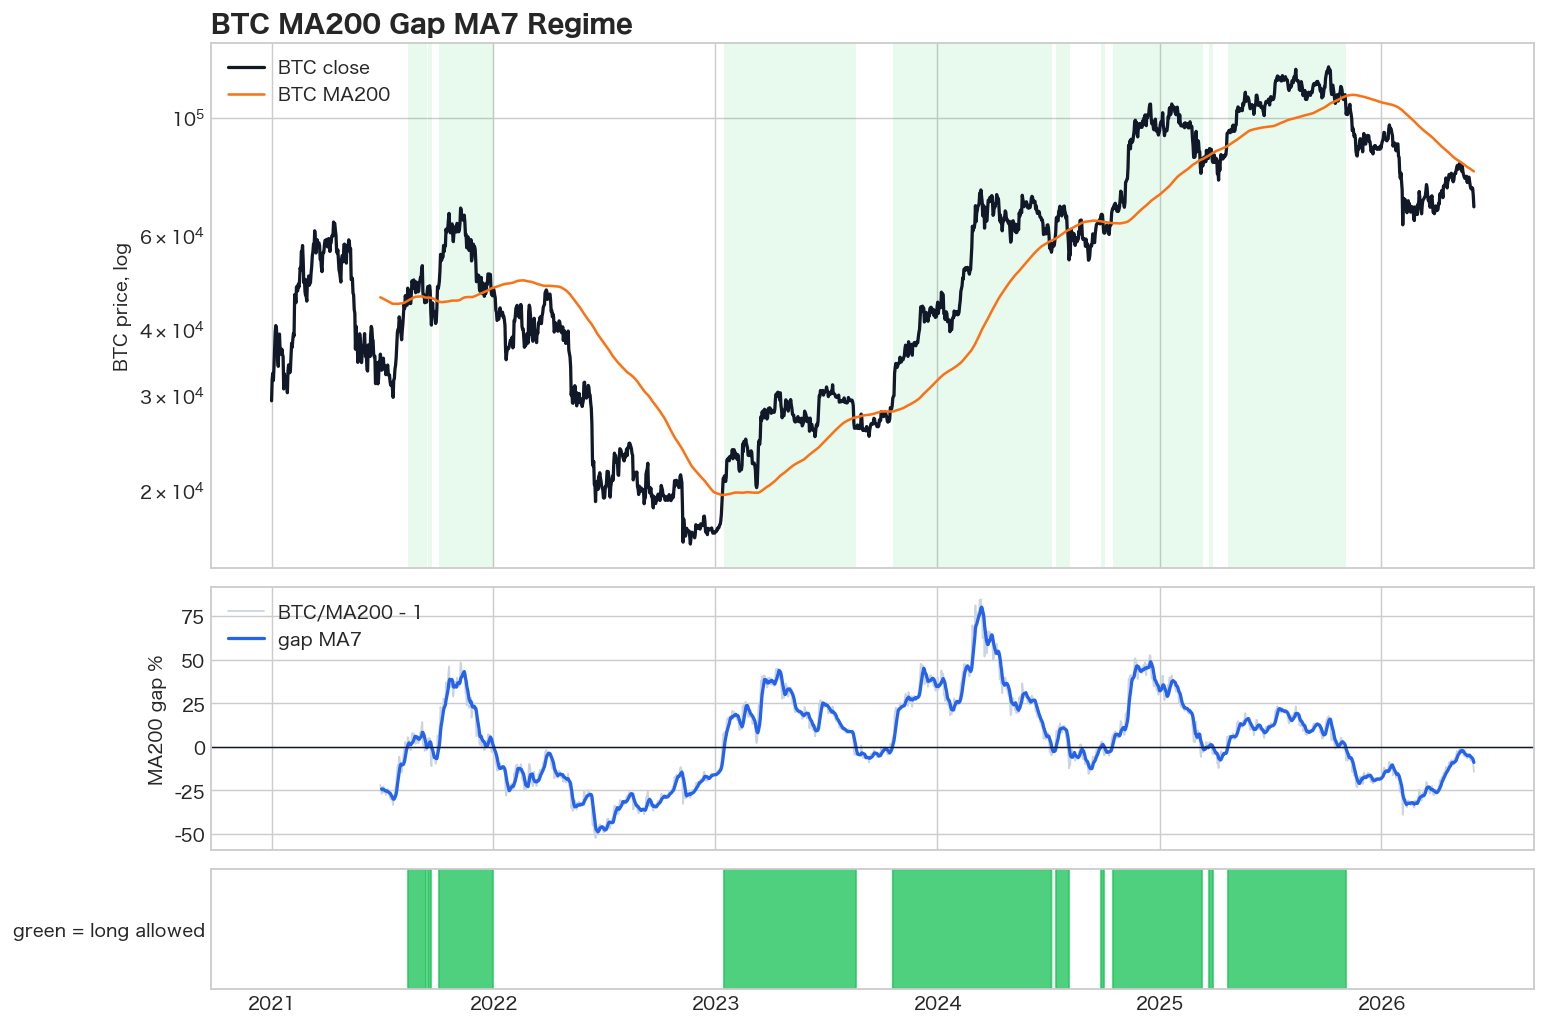

,latest,current_gate,btc_close,ma200,gap_ma7_pct,active_rate
0,2026-06-02,LONG OFF,67964.3,79246.0215,-8.8641,0.4972


In [9]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2.2, 1.1, 0.5]})
start = pd.Timestamp("2021-01-01")
b = btc[btc["date"] >= start].copy()

ax = axes[0]
ax.plot(b["date"], b["close"], color="#111827", lw=1.8, label="BTC close")
ax.plot(b["date"], b["ma200"], color="#f97316", lw=1.4, label="BTC MA200")
ax.set_yscale("log")
ax.set_ylabel("BTC price, log")
ax.set_title("BTC MA200 Gap MA7 Regime", loc="left", fontsize=14, fontweight="bold")
ax.legend(loc="upper left")
for _, row in b[b["btc_long_allowed"]].iterrows():
    ax.axvspan(row["date"], row["date"] + pd.Timedelta(days=1), color="#22c55e", alpha=0.10, lw=0)

ax = axes[1]
ax.plot(b["date"], b["btc_ma200_gap"] * 100, color="#cbd5e1", lw=1.0, label="BTC/MA200 - 1")
ax.plot(b["date"], b["btc_ma200_gap_ma7"] * 100, color="#2563eb", lw=1.8, label="gap MA7")
ax.axhline(0, color="#111827", lw=0.8)
ax.set_ylabel("MA200 gap %")
ax.legend(loc="upper left")

ax = axes[2]
ax.fill_between(b["date"], 0, 1, where=b["btc_long_allowed"].fillna(False), color="#22c55e", alpha=0.8, step="post")
ax.set_yticks([0.5], ["green = long allowed"])
ax.set_ylim(0, 1)
ax.grid(False)

fig.tight_layout()
savefig(fig, "04_btc_ma200_gap_ma7_regime_recomputed.png")
plt.show()

readout = pd.DataFrame({
    "latest": [b["date"].max().date()],
    "current_gate": ["LONG ON" if bool(b["btc_long_allowed"].iloc[-1]) else "LONG OFF"],
    "btc_close": [b["close"].iloc[-1]],
    "ma200": [b["ma200"].iloc[-1]],
    "gap_ma7_pct": [b["btc_ma200_gap_ma7"].iloc[-1] * 100],
    "active_rate": [b["btc_long_allowed"].mean()],
})
display(readout.round(4))

## 7. 先物乖離を主軸にしたロング戦略は弱い

BTC MA200 gap MA7のレジームは見た目には良さそうでした。  
しかし、レジームは「ロングしてよい地合い」であって、「どの銘柄を買うか」ではありません。

そこで、A0周辺の先物乖離ロジックをロングに転用できるか確認しました。  
結論は先物乖離を主軸にしたロングは採用水準に届きませんでした。

検証した代表例:

- A: A0スコア上位をロング
- B: 直近リターン上位をロング
- C: basis demeanが低い銘柄をロング
- それぞれ `btc_ma200_gap_ma7 > 0` のレジームを併用

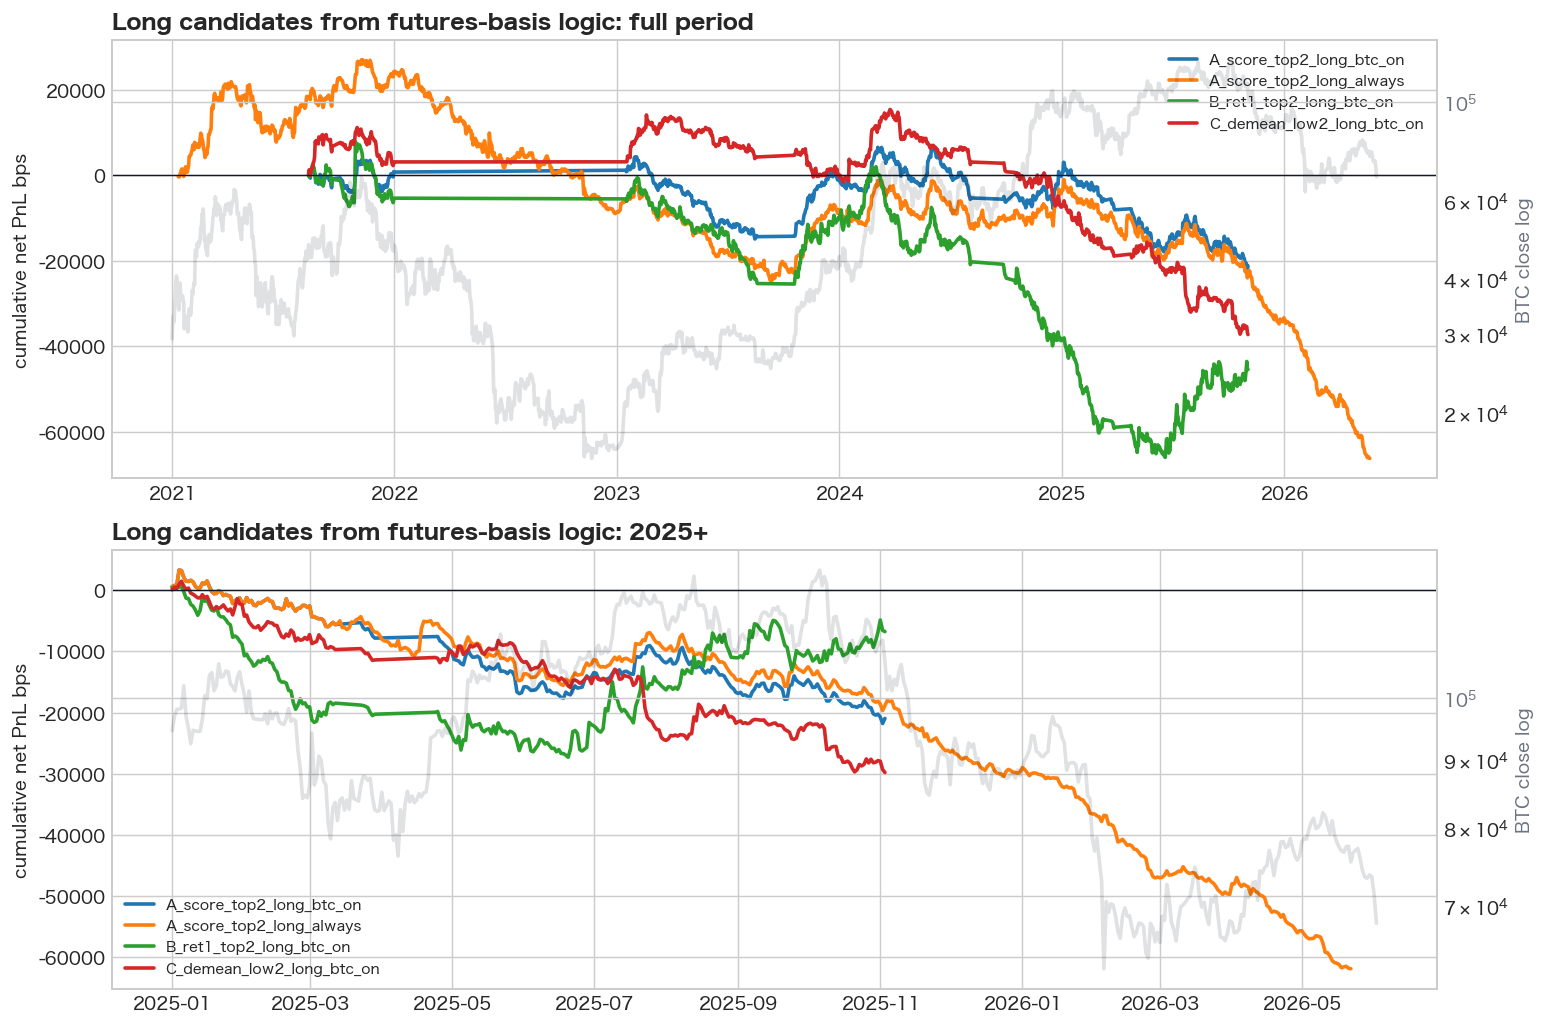

,days,cum_bps,avg_bps,sharpe,max_dd_bps,win_rate
label,,,,,,
A_score_top2_long_btc_on,272,-20953.814,-77.036,-1.941,-25097.886,0.415
A_score_top2_long_always,507,-61899.868,-122.090,-3.219,-65215.771,0.361
B_ret1_top2_long_btc_on,272,-6749.333,-24.814,-0.349,-27971.816,0.397
C_demean_low2_long_btc_on,272,-29797.008,-109.548,-2.501,-31296.401,0.434


In [10]:
long_candidates = {}
_, long_candidates["A_score_top2_long_btc_on"] = select_positions(
    sig, "score_a0", highest=True, top_n=2, lag=1, direction="long", cost_bps=DEFAULT_COST_BPS,
    eligible=lambda x: x["btc_long_allowed"].fillna(False), label="A_score_top2_long_btc_on"
)
_, long_candidates["A_score_top2_long_always"] = select_positions(
    sig, "score_a0", highest=True, top_n=2, lag=1, direction="long", cost_bps=DEFAULT_COST_BPS,
    label="A_score_top2_long_always"
)
_, long_candidates["B_ret1_top2_long_btc_on"] = select_positions(
    sig, "ret1", highest=True, top_n=2, lag=1, direction="long", cost_bps=DEFAULT_COST_BPS,
    eligible=lambda x: x["btc_long_allowed"].fillna(False), label="B_ret1_top2_long_btc_on"
)
_, long_candidates["C_demean_low2_long_btc_on"] = select_positions(
    sig, "basis_demean", highest=False, top_n=2, lag=1, direction="long", cost_bps=DEFAULT_COST_BPS,
    eligible=lambda x: x["btc_long_allowed"].fillna(False), label="C_demean_low2_long_btc_on"
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
for ax, start, title in [
    (axes[0], "2021-01-01", "Long candidates from futures-basis logic: full period"),
    (axes[1], "2025-01-01", "Long candidates from futures-basis logic: 2025+"),
]:
    for label, daily in long_candidates.items():
        s = daily[daily.index >= pd.Timestamp(start)]
        ax.plot(s.index, s.cumsum(), lw=2, label=label)
    ax.axhline(0, color="#111827", lw=0.8)
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_ylabel("cumulative net PnL bps")
    ax.legend(loc="best", fontsize=8)
    add_btc_background(ax, start=start)
fig.tight_layout()
savefig(fig, "05_futures_basis_long_candidates_are_weak.png")
plt.show()

display(stats_table(long_candidates, start="2025-01-01"))

## 8. backwardationをロングしない

次に考えたのは、A0ショートの反対側です。

```text
A0ショート:
future > spot
先物が現物より高く乖離
先物が現物側へ戻るなら、ショートで利益
```

これを逆にすると、以下のロング仮説になります。

```text
backwardation:
future < spot
先物が現物より安く乖離
先物が現物側へ戻るなら、ロングで利益
```

一見自然ですが、検証すると弱いです。  
理由は、`future < spot` が「割安」ではなく「先物市場で売り圧が強い」サインになりやすいためです。

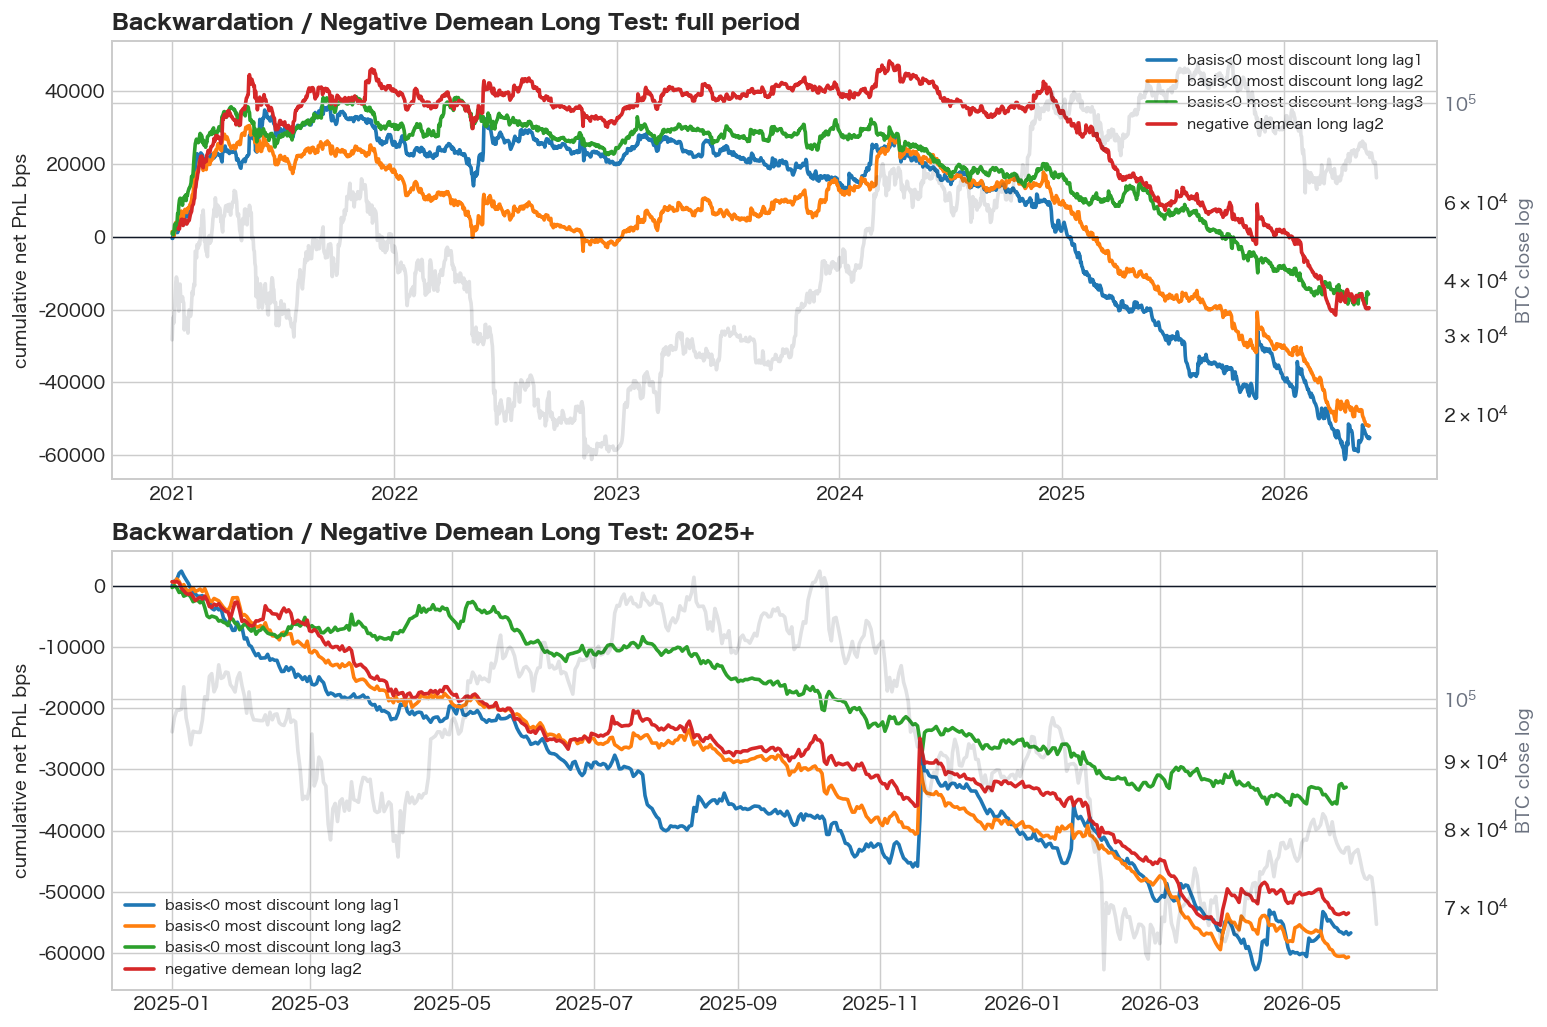

,days,cum_bps,avg_bps,sharpe,max_dd_bps,win_rate
label,,,,,,
basis<0 most discount long lag1,507,-56735.214,-111.904,-1.709,-65220.154,0.396
basis<0 most discount long lag2,506,-60690.152,-119.941,-2.381,-62009.872,0.387
basis<0 most discount long lag3,505,-32906.236,-65.161,-1.598,-35899.437,0.440
negative demean long lag2,506,-53484.144,-105.700,-2.086,-56237.544,0.397


In [11]:
backwardation_long = {}
for lag in [1, 2, 3]:
    _, daily = select_positions(
        sig, "basis", highest=False, top_n=2, lag=lag, direction="long", cost_bps=DEFAULT_COST_BPS,
        eligible=lambda x: x["basis"] < 0, label=f"backwardation_long_lag{lag}"
    )
    backwardation_long[f"basis<0 most discount long lag{lag}"] = daily

_, demean_long = select_positions(
    sig, "basis_demean", highest=False, top_n=2, lag=2, direction="long", cost_bps=DEFAULT_COST_BPS,
    eligible=lambda x: x["basis_demean"] < 0, label="negative_demean_long_lag2"
)
backwardation_long["negative demean long lag2"] = demean_long

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
for ax, start, title in [
    (axes[0], "2021-01-01", "Backwardation / Negative Demean Long Test: full period"),
    (axes[1], "2025-01-01", "Backwardation / Negative Demean Long Test: 2025+"),
]:
    for label, daily in backwardation_long.items():
        s = daily[daily.index >= pd.Timestamp(start)]
        ax.plot(s.index, s.cumsum(), lw=2, label=label)
    ax.axhline(0, color="#111827", lw=0.8)
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_ylabel("cumulative net PnL bps")
    ax.legend(loc="best", fontsize=8)
    add_btc_background(ax, start=start)
fig.tight_layout()
savefig(fig, "06_backwardation_long_is_weak_recomputed.png")
plt.show()

display(stats_table(backwardation_long, start="2025-01-01"))

## 9. S0ロジック: backwardationを弱さ継続ショートとして使う

`basis < 0` は、先物が現物より安い状態です。ロングの安値拾いではなく、先物市場側の売り圧が強い「弱さ継続」の候補として扱うと、S0の発想になります。

S0:

1. `basis = future_close / spot_close - 1`
2. `basis < 0` の銘柄だけを対象
3. `basis` が最もマイナスのTop2を選ぶ
4. シグナル日から2日後のOpenでショート
5. 同日Closeで決済
6. 日次PnLはTop2の平均、コスト込み

ここでS0は、A0の置き換えではなく、別枠の弱さ継続ショート候補です。

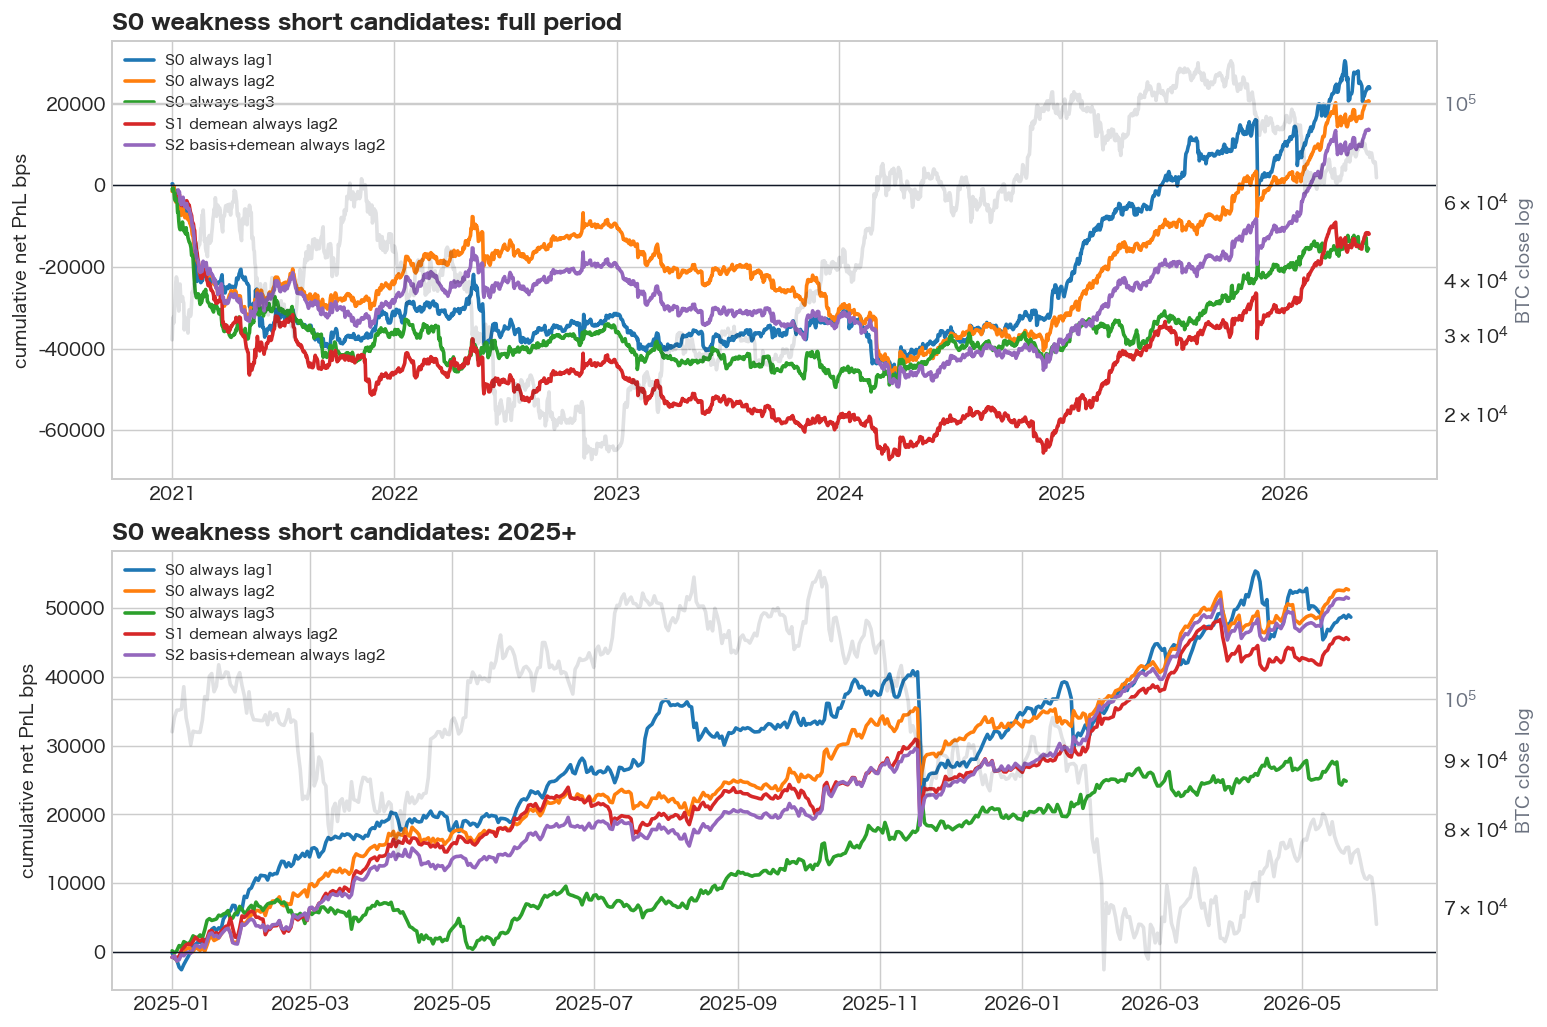

,days,cum_bps,avg_bps,sharpe,max_dd_bps,win_rate
label,,,,,,
S0 always lag1,507,48623.214,95.904,1.465,-18568.805,0.592
S0 always lag2,506,52594.152,103.941,2.063,-11153.760,0.597
S0 always lag3,505,24826.236,49.161,1.206,-7237.892,0.547
S1 demean always lag2,506,45388.144,89.700,1.770,-11153.760,0.593
S2 basis+demean always lag2,506,51365.961,101.514,2.045,-11153.760,0.593


In [12]:
s0_curves = {}
for lag in [1, 2, 3]:
    _, daily = select_positions(
        sig, "basis", highest=False, top_n=2, lag=lag, direction="short", cost_bps=DEFAULT_COST_BPS,
        eligible=lambda x: x["basis"] < 0, label=f"S0_basis_negative_short_lag{lag}"
    )
    s0_curves[f"S0 always lag{lag}"] = daily

_, s1 = select_positions(
    sig, "basis_demean", highest=False, top_n=2, lag=2, direction="short", cost_bps=DEFAULT_COST_BPS,
    label="S1_demean_low_short_lag2"
)
s0_curves["S1 demean always lag2"] = s1

_, s2 = select_positions(
    sig, "basis", highest=False, top_n=2, lag=2, direction="short", cost_bps=DEFAULT_COST_BPS,
    eligible=lambda x: (x["basis"] < 0) & (x["basis_demean"] < 0),
    label="S2_basis_and_demean_short_lag2"
)
s0_curves["S2 basis+demean always lag2"] = s2

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
for ax, start, title in [
    (axes[0], "2021-01-01", "S0 weakness short candidates: full period"),
    (axes[1], "2025-01-01", "S0 weakness short candidates: 2025+"),
]:
    for label, daily in s0_curves.items():
        s = daily[daily.index >= pd.Timestamp(start)]
        ax.plot(s.index, s.cumsum(), lw=2, label=label)
    ax.axhline(0, color="#111827", lw=0.8)
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_ylabel("cumulative net PnL bps")
    ax.legend(loc="best", fontsize=8)
    add_btc_background(ax, start=start)
fig.tight_layout()
savefig(fig, "07_s0_weakness_short_recomputed.png")
plt.show()

display(stats_table(s0_curves, start="2025-01-01"))

## 10. コストストレス

S0 always lag2 に対して、0bps、8bps、10bps、20bpsの往復コストを比較します。実運用では手数料条件に合わせて10bps程度を見るのが自然です。

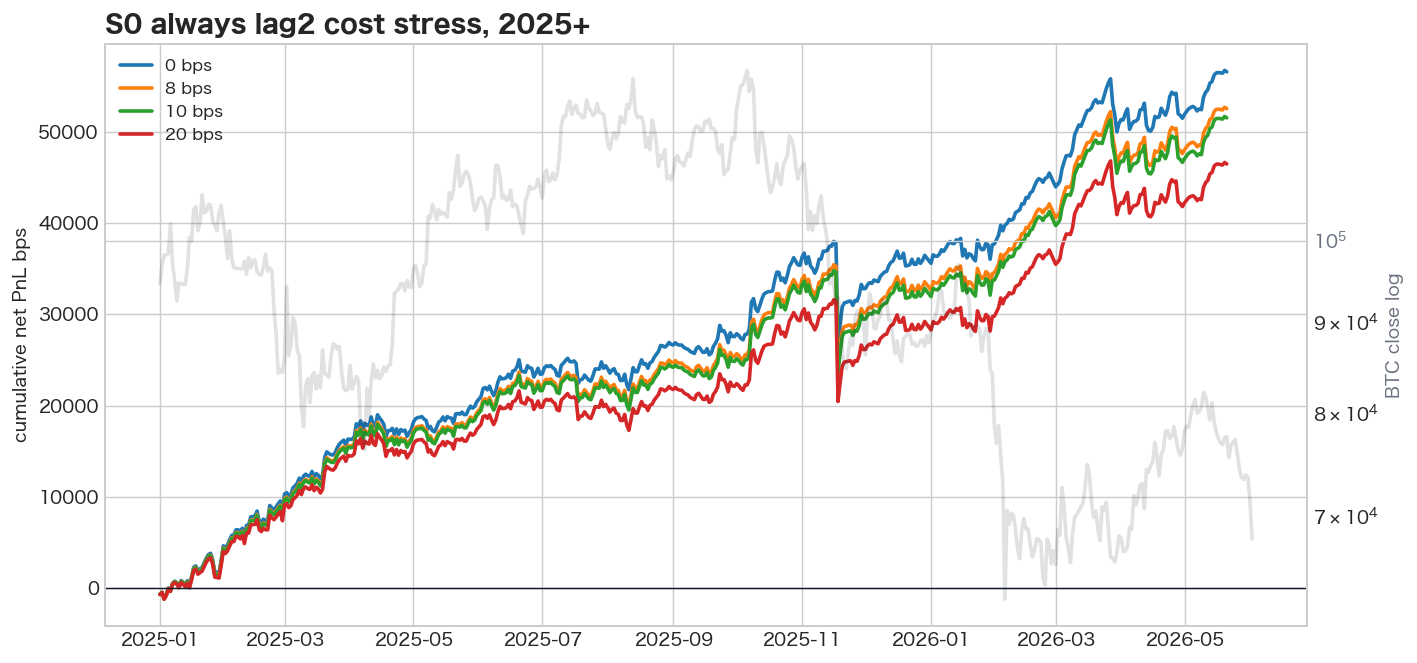

,days,cum_bps,avg_bps,sharpe,max_dd_bps,win_rate
label,,,,,,
0 bps,506,56642.152,111.941,2.222,-11137.76,0.607
8 bps,506,52594.152,103.941,2.063,-11153.76,0.597
10 bps,506,51582.152,101.941,2.023,-11157.76,0.597
20 bps,506,46522.152,91.941,1.825,-11177.76,0.589


In [13]:
cost_curves = {}
for cost in [0, 8, 10, 20]:
    _, d = select_positions(
        sig, "basis", highest=False, top_n=2, lag=2, direction="short", cost_bps=float(cost),
        eligible=lambda x: x["basis"] < 0, label=f"S0_lag2_cost_{cost}bps"
    )
    cost_curves[f"{cost} bps"] = d

plot_cum(cost_curves, "S0 always lag2 cost stress, 2025+", "08_s0_lag2_cost_stress_recomputed.png", start="2025-01-01")
display(stats_table(cost_curves, start="2025-01-01"))

## 11. 10万円スタート、レバレッジ1倍、投入率別の複利イメージ

これは投資助言ではなく、S0 lag2を日次平均PnLとして機械的に複利換算した確認です。投入率30%なら、1日あたりの口座変動は `daily_bps / 10000 * 0.30` として計算します。

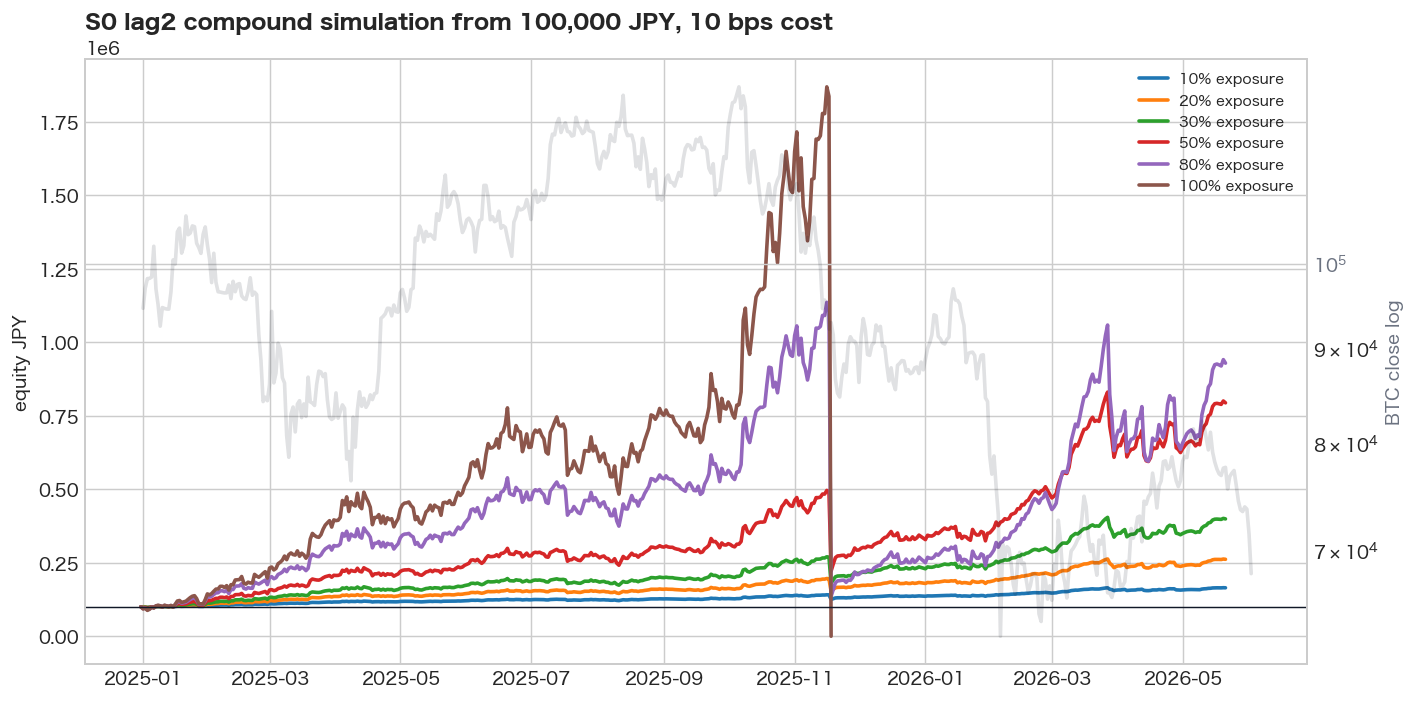

,exposure,final_jpy,return_x,max_dd_pct,bankrupt_date
0,10%,164691.044,1.647,-11.139,
1,20%,261606.088,2.616,-22.239,
2,30%,398943.028,3.989,-33.302,
3,50%,793768.649,7.938,-55.312,
4,80%,928800.772,9.288,-88.042,
5,100%,0.000,0.000,-100.000,2025-11-18


In [14]:
base_daily = cost_curves["10 bps"].loc[lambda s: s.index >= pd.Timestamp("2025-01-01")]
initial_capital = 100_000
exposures = [0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
equity_curves = {}
compound_rows = []

for exp in exposures:
    eq = [initial_capital]
    bankrupt_date = None
    for dt, bps in base_daily.items():
        r = bps / 10000 * exp
        nxt = eq[-1] * (1 + r)
        if nxt <= 0:
            bankrupt_date = dt
            eq.append(0.0)
            break
        eq.append(nxt)
    idx = [base_daily.index[0] - pd.Timedelta(days=1)] + list(base_daily.index[: len(eq) - 1])
    s = pd.Series(eq, index=idx)
    equity_curves[f"{int(exp*100)}% exposure"] = s
    dd = s / s.cummax() - 1
    compound_rows.append({
        "exposure": f"{int(exp*100)}%",
        "final_jpy": s.iloc[-1],
        "return_x": s.iloc[-1] / initial_capital,
        "max_dd_pct": dd.min() * 100,
        "bankrupt_date": "" if bankrupt_date is None else bankrupt_date.date(),
    })

fig, ax = plt.subplots(figsize=(11, 5.5))
for label, s in equity_curves.items():
    ax.plot(s.index, s.values, lw=2, label=label)
ax.axhline(initial_capital, color="#111827", lw=0.8)
ax.set_title("S0 lag2 compound simulation from 100,000 JPY, 10 bps cost", loc="left", fontweight="bold")
ax.set_ylabel("equity JPY")
ax.legend(loc="best", fontsize=8)
add_btc_background(ax, start="2025-01-01")
fig.tight_layout()
savefig(fig, "09_s0_lag2_compound_100k_exposure_recomputed.png")
plt.show()

display(pd.DataFrame(compound_rows).round(3))

## 12. 標準化Zスコアも検討したが、S0 raw basisを超えなかった

`basis_z = (basis - 過去21日平均) / 過去21日標準偏差` も検証します。ただしZスコアは履歴が足りない新規銘柄を落としやすく、今回のS0候補ではraw basisの方が素直でした。

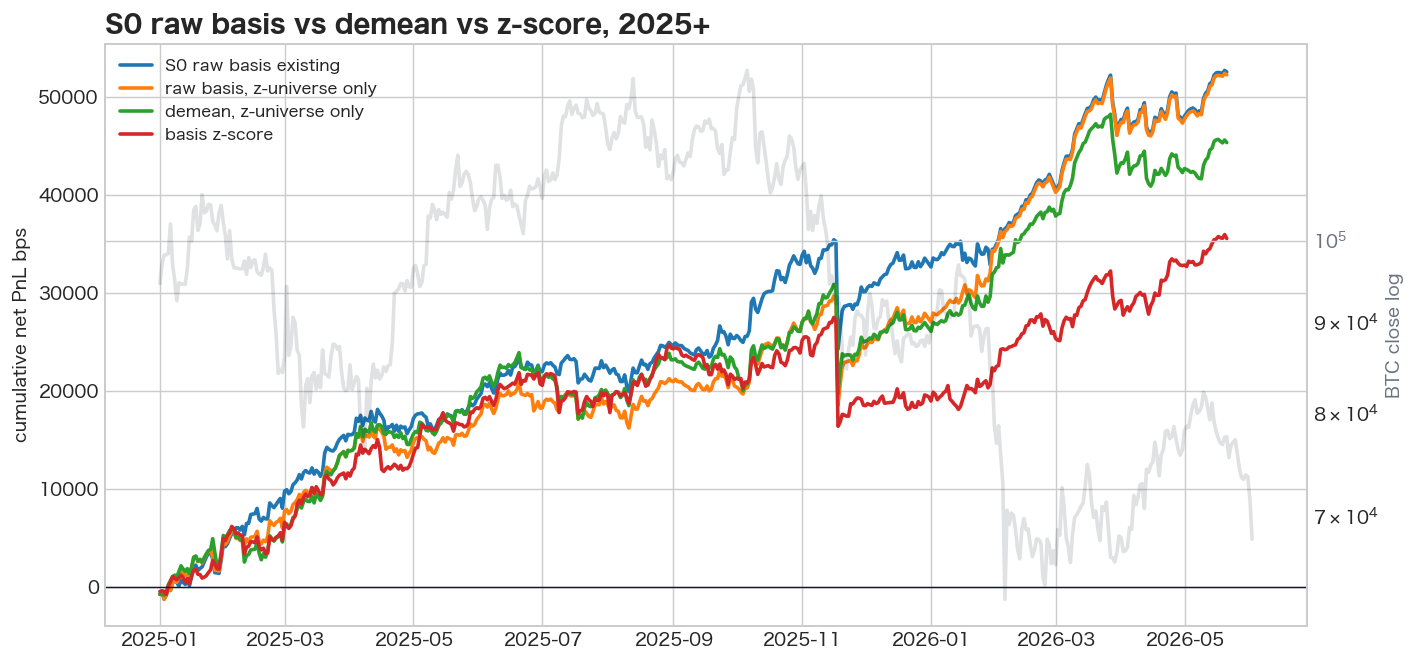

,days,cum_bps,avg_bps,sharpe,max_dd_bps,win_rate
label,,,,,,
S0 raw basis existing,506,52594.152,103.941,2.063,-11153.760,0.597
"raw basis, z-universe only",506,52299.227,103.358,2.074,-11153.760,0.597
"demean, z-universe only",506,45388.144,89.700,1.770,-11153.760,0.593
basis z-score,506,35598.686,70.353,1.459,-11109.212,0.569


In [15]:
z_curves = {}
_, z_curves["S0 raw basis existing"] = select_positions(
    sig, "basis", highest=False, top_n=2, lag=2, direction="short", cost_bps=DEFAULT_COST_BPS,
    eligible=lambda x: x["basis"] < 0, label="raw_existing"
)
_, z_curves["raw basis, z-universe only"] = select_positions(
    sig, "basis", highest=False, top_n=2, lag=2, direction="short", cost_bps=DEFAULT_COST_BPS,
    eligible=lambda x: (x["basis"] < 0) & x["basis_z"].notna(), label="raw_common"
)
_, z_curves["demean, z-universe only"] = select_positions(
    sig, "basis_demean", highest=False, top_n=2, lag=2, direction="short", cost_bps=DEFAULT_COST_BPS,
    eligible=lambda x: x["basis_z"].notna(), label="demean_common"
)
_, z_curves["basis z-score"] = select_positions(
    sig, "basis_z", highest=False, top_n=2, lag=2, direction="short", cost_bps=DEFAULT_COST_BPS,
    eligible=lambda x: x["basis_z"].notna(), label="zscore"
)

plot_cum(z_curves, "S0 raw basis vs demean vs z-score, 2025+", "10_s0_zscore_comparison_recomputed.png", start="2025-01-01")
display(stats_table(z_curves, start="2025-01-01"))

## 13. なぜ2024年末から機能していそうに見えるのか

月次に分解すると、2024年11月はまだ弱く、2024年12月以降にS0の見え方が変わっています。ここから先は追加仮説として扱います。

次に見る候補:

1. 新規上場・上場後日数: 利益が上場後90日以内に偏っていないか
2. BTC dominance / Altcoin Season Index: BTC主導からアルト投機へのローテーション期に効いていないか
3. 銘柄の流動性・時価総額階層: 低流動性・新興アルトに利益が偏っていないか

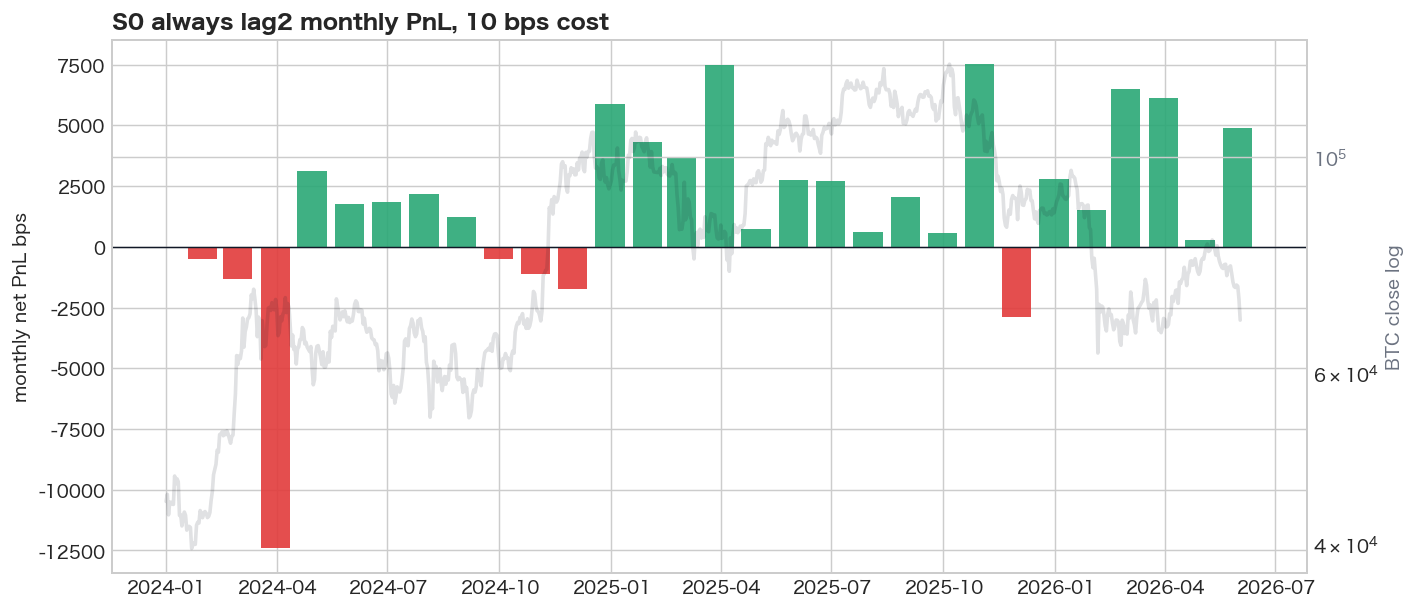

,monthly_bps
date,
2024-12-31,5889.8
2025-01-31,4291.7
2025-02-28,3653.5
2025-03-31,7479.8
2025-04-30,743.7
2025-05-31,2734.7
2025-06-30,2722.6
2025-07-31,622.4
2025-08-31,2036.0


In [16]:
s0_10 = cost_curves["10 bps"].copy()
monthly = s0_10.resample("M").sum()
monthly = monthly[monthly.index >= pd.Timestamp("2024-01-01")]

fig, ax = plt.subplots(figsize=(11, 4.8))
colors = np.where(monthly >= 0, "#2aa876", "#e23b3b")
ax.bar(monthly.index, monthly.values, width=24, color=colors, alpha=0.9)
ax.axhline(0, color="#111827", lw=0.8)
ax.set_title("S0 always lag2 monthly PnL, 10 bps cost", loc="left", fontweight="bold")
ax.set_ylabel("monthly net PnL bps")
add_btc_background(ax, start="2024-01-01")
fig.tight_layout()
savefig(fig, "11_s0_monthly_pnl_2024_onward_recomputed.png")
plt.show()

display(monthly.rename("monthly_bps").to_frame().round(1).tail(18))

## 14. ここまでのまとめ

- A0フォワードの負けは、BTC方向だけでは説明しにくい。
- 個別アルトのパンプ継続、特にrank2側の弱さを疑った。
- rank2を単純に消すと長期では弱くなりやすい。
- OI、FR、BTC超過リターン、出来高、高値引け、cooldownは観察指標として有用だが、A0 TOP2を明確に改善する強いフィルターにはまだなっていない。
- BTC MA200 gap MA7はレジーム判定として見た目は良い。
- ただし、先物乖離を主軸にしたロング戦略は弱かった。
- `basis < 0` を「安いからロング」ではなく「先物市場の弱さ継続」と解釈すると、S0 weak shortが見えた。
- 現時点の候補は `S0 raw basis, basis < 0, Top2, lag2 short`。
- 次回は、上場後日数、BTC dominance / Altcoin Season、流動性・時価総額階層で、2024年末以降に効き始めた理由を検証する。

---
## 免責事項

* 本資料の実行・利用により生成または保存されるデータの管理は利用者の責任で行ってください。
* お客様によるコンテンツの利用等に関して生じうるいかなる損害について責任を負いません。
* 執筆者によって提供されたいかなる見解または意見は当該執筆者自身のその時点における見解や分析であって、当社の見解、分析ではありません。
* 暗号資産（仮想通貨）は法定通貨ではありません。
* また、法定通貨とは異なり、日本円やドルなどのように国又は特定の者によりその価値を保証されているものではありません。
* 暗号資産の価格の変動等により損失が発生する可能性があります。
* 暗号資産は代価の弁済を受ける者の同意がある場合に限り、代価の弁済のために使用することができます。
* 暗号資産信用取引は、価格の変動等により当初差入れた保証金を上回る損失が発生する可能性があります。十分なご理解の上で、自己責任にてお取引ください。
* お取引を行う際には、弊社のWebサイトに記載の「契約締結前交付書面兼説明書」「各種規約」「取引ルール」をご確認のうえ、取引内容を十分に理解し、お客様ご自身の責任と判断を持って行ってください。